# Dry Bean 数据集聚类分析实验

---

## 实验基本信息

- **课程名称**：机器学习
- **实验名称**：聚类实验（自选任务）
- **学生身份**：大三计算机专业学生
- **实验日期**：2025年12月

---

## 实验内容概述

本实验使用 Kaggle 上的 Dry Bean Dataset（干豆数据集）进行聚类分析。该数据集包含 7 种不同类型干豆的 16 个几何特征，我们将使用无监督学习方法对数据进行聚类，并对比不同聚类算法的效果。

**主要任务：**
1. 对 Dry Bean 数据集进行探索性数据分析和预处理
2. 实现并对比 K-Means、层次聚类（Agglomerative Clustering）、DBSCAN 三种聚类算法
3. 使用内部评价指标（轮廓系数、CH 指数、DB 指数）和外部评价指标（ARI、NMI）评估聚类效果
4. 设计自定义聚类视角，从不同特征子集角度分析数据
5. 对聚类结果进行可视化和深入分析


---

# 一、实验目的

本实验的主要目的包括：

1. **理解无监督学习**：掌握聚类分析的基本概念，理解聚类与分类的区别——聚类是在没有标签的情况下发现数据的内在结构。

2. **掌握聚类算法**：学习并实践 K-Means、层次聚类（Agglomerative Clustering）、DBSCAN 等经典聚类算法的原理和使用方法。

3. **学会评价聚类效果**：掌握内部评价指标（轮廓系数、Calinski-Harabasz 指数、Davies-Bouldin 指数）和外部评价指标（调整兰德指数 ARI、归一化互信息 NMI）的计算和解读。

4. **数据分析与可视化**：学会对真实数据集进行预处理、降维可视化，并从多个角度分析聚类结果。

5. **自定义聚类视角**：探索从不同特征子集进行聚类分析，理解特征选择对聚类结果的影响。

本实验将使用 Dry Bean 数据集，对比至少两种聚类算法的效果，并设计自定义的聚类视角进行深入分析。


---

# 二、数据集与预处理

## 2.1 Data Prepare（数据准备）

### 2.1.1 导入必要的库

首先导入实验所需的 Python 库，包括：
- **numpy、pandas**：数据处理
- **matplotlib、seaborn**：数据可视化
- **sklearn**：机器学习算法和评价指标

> **注意**：请确保数据文件路径正确。本实验假设数据文件位于当前目录下，文件名为 `Dry_Bean.csv`。如果您的文件路径不同，请修改下方代码中的 `DATA_PATH` 变量。


In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings

# 聚类算法
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# 数据预处理
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 降维
from sklearn.decomposition import PCA

# 聚类评价指标
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# 设置随机种子，保证结果可复现
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 支持中文显示
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
sns.set_palette("husl")

# 忽略警告
warnings.filterwarnings('ignore')

print("所有库导入成功！")


所有库导入成功！


### 2.1.2 加载数据集

Dry Bean Dataset 是一个关于干豆分类的数据集，包含 7 种不同类型干豆的几何特征。数据集来源于 Kaggle。

**数据集特征说明：**
- **Area**: 豆子区域面积
- **Perimeter**: 豆子周长
- **MajorAxisLength**: 最长轴长度
- **MinorAxisLength**: 最短轴长度
- **AspectRation**: 长宽比
- **Eccentricity**: 离心率
- **ConvexArea**: 凸包面积
- **EquivDiameter**: 等效直径
- **Extent**: 范围
- **Solidity**: 实心度
- **roundness**: 圆度
- **Compactness**: 紧致度
- **ShapeFactor1-4**: 形状因子 1-4
- **Class**: 豆子类别（目标变量，聚类时不作为输入）


In [2]:
# ============================================
# 数据文件路径配置
# 请根据实际情况修改以下路径
# ============================================

# 方式1：读取 CSV 文件（推荐）
DATA_PATH = "./Dry_Bean.csv"

# 方式2：如果是 Excel 文件，请取消注释下一行并注释上一行
# DATA_PATH = "./Dry_Bean_Dataset.xlsx"

# 读取数据
try:
    if DATA_PATH.endswith('.csv'):
        df = pd.read_csv(DATA_PATH)
    else:
        df = pd.read_excel(DATA_PATH)
    print(f"数据加载成功！文件路径: {DATA_PATH}")
except FileNotFoundError:
    print(f"错误：找不到文件 {DATA_PATH}")
    print("请检查文件路径是否正确，或将数据文件放到当前目录下。")


数据加载成功！文件路径: ./Dry_Bean.csv


In [3]:
# 查看数据基本信息
print("=" * 60)
print("数据集基本信息")
print("=" * 60)
print(f"\n数据维度: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f"特征数量: {df.shape[1] - 1} 个（不含类别标签）")
print(f"\n前5行数据:")
df.head()


数据集基本信息

数据维度: 13611 行 × 17 列
特征数量: 16 个（不含类别标签）

前5行数据:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
# 查看数据类型
print("数据类型信息:")
print("-" * 40)
df.info()


数据类型信息:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class    

In [5]:
# 查看基础统计量
print("基础统计量:")
df.describe()


基础统计量:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


类别分布:
----------------------------------------
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

共有 7 种豆子类别


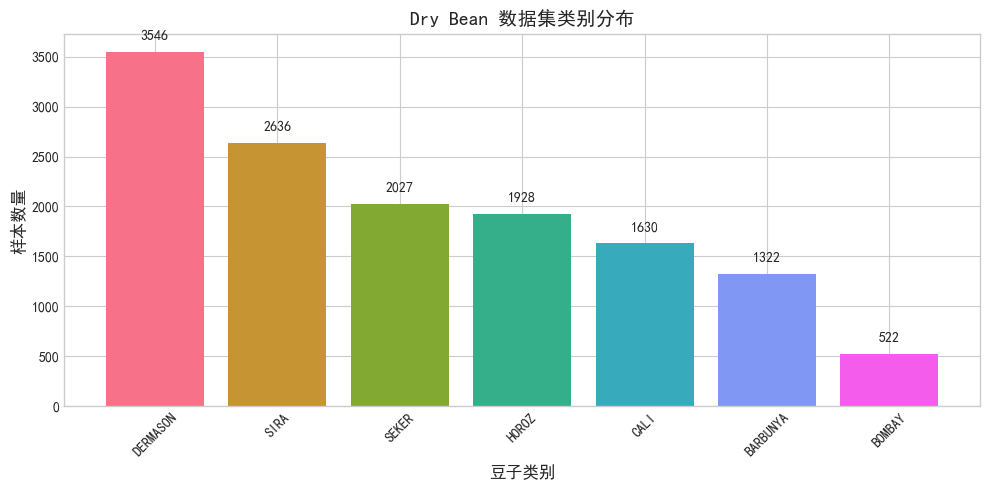

In [6]:
# 查看类别分布
print("类别分布:")
print("-" * 40)
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\n共有 {len(class_counts)} 种豆子类别")

# 可视化类别分布
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=sns.color_palette("husl", len(class_counts)))
ax.set_xlabel('豆子类别', fontsize=12)
ax.set_ylabel('样本数量', fontsize=12)
ax.set_title('Dry Bean 数据集类别分布', fontsize=14)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            str(count), ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 2.2 Data Preprocess（数据预处理）

### 2.2.1 缺失值与重复值检测

在进行聚类分析之前，需要检查数据的完整性，处理可能存在的缺失值和重复值。


In [7]:
# 检查缺失值
print("缺失值检查:")
print("-" * 40)
missing_values = df.isnull().sum()
print(missing_values)
print(f"\n总缺失值数量: {missing_values.sum()}")

# 检查重复值
print("\n重复值检查:")
print("-" * 40)
duplicates = df.duplicated().sum()
print(f"重复行数量: {duplicates}")

# 如果存在重复值，删除重复行
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"已删除 {duplicates} 行重复数据")
    print(f"处理后数据维度: {df.shape}")


缺失值检查:
----------------------------------------
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

总缺失值数量: 0

重复值检查:
----------------------------------------
重复行数量: 68
已删除 68 行重复数据
处理后数据维度: (13543, 17)


### 2.2.2 特征与标签分离

将数据集分为特征矩阵 X 和标签向量 y。需要注意的是，在聚类分析中，标签 y 不参与训练过程（无监督学习），但可以用于后续的评价和对比。


In [8]:
# 分离特征和标签
feature_columns = df.columns.drop('Class')
X = df[feature_columns].values
y_original = df['Class'].values

# 将类别标签编码为数字（用于后续评价指标计算）
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_original)

print("特征矩阵 X 的形状:", X.shape)
print("标签向量 y 的形状:", y.shape)
print("\n特征列名称:")
print(list(feature_columns))
print("\n类别编码映射:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} -> {i}")


特征矩阵 X 的形状: (13543, 16)
标签向量 y 的形状: (13543,)

特征列名称:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

类别编码映射:
  BARBUNYA -> 0
  BOMBAY -> 1
  CALI -> 2
  DERMASON -> 3
  HOROZ -> 4
  SEKER -> 5
  SIRA -> 6


### 2.2.3 特征标准化

由于不同特征的量纲和取值范围差异很大（如 Area 的值在数万级别，而 ShapeFactor 的值在 0-1 之间），直接进行聚类会导致某些特征主导距离计算。因此，需要对特征进行标准化处理，使每个特征的均值为 0，标准差为 1。

**标准化公式：** $ z = \frac{x - \mu}{\sigma} $

其中 $\mu$ 为特征均值，$\sigma$ 为特征标准差。


In [9]:
# 特征标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 验证标准化效果
print("标准化前后的特征统计量对比:")
print("-" * 60)
print("\n标准化前（原始数据）:")
print(f"  均值范围: [{X.mean(axis=0).min():.4f}, {X.mean(axis=0).max():.4f}]")
print(f"  标准差范围: [{X.std(axis=0).min():.4f}, {X.std(axis=0).max():.4f}]")

print("\n标准化后:")
print(f"  均值范围: [{X_scaled.mean(axis=0).min():.6f}, {X_scaled.mean(axis=0).max():.6f}]")
print(f"  标准差范围: [{X_scaled.std(axis=0).min():.6f}, {X_scaled.std(axis=0).max():.6f}]")


标准化前后的特征统计量对比:
------------------------------------------------------------

标准化前（原始数据）:
  均值范围: [0.0017, 53767.9867]
  标准差范围: [0.0006, 29843.1467]

标准化后:
  均值范围: [-0.000000, 0.000000]
  标准差范围: [1.000000, 1.000000]


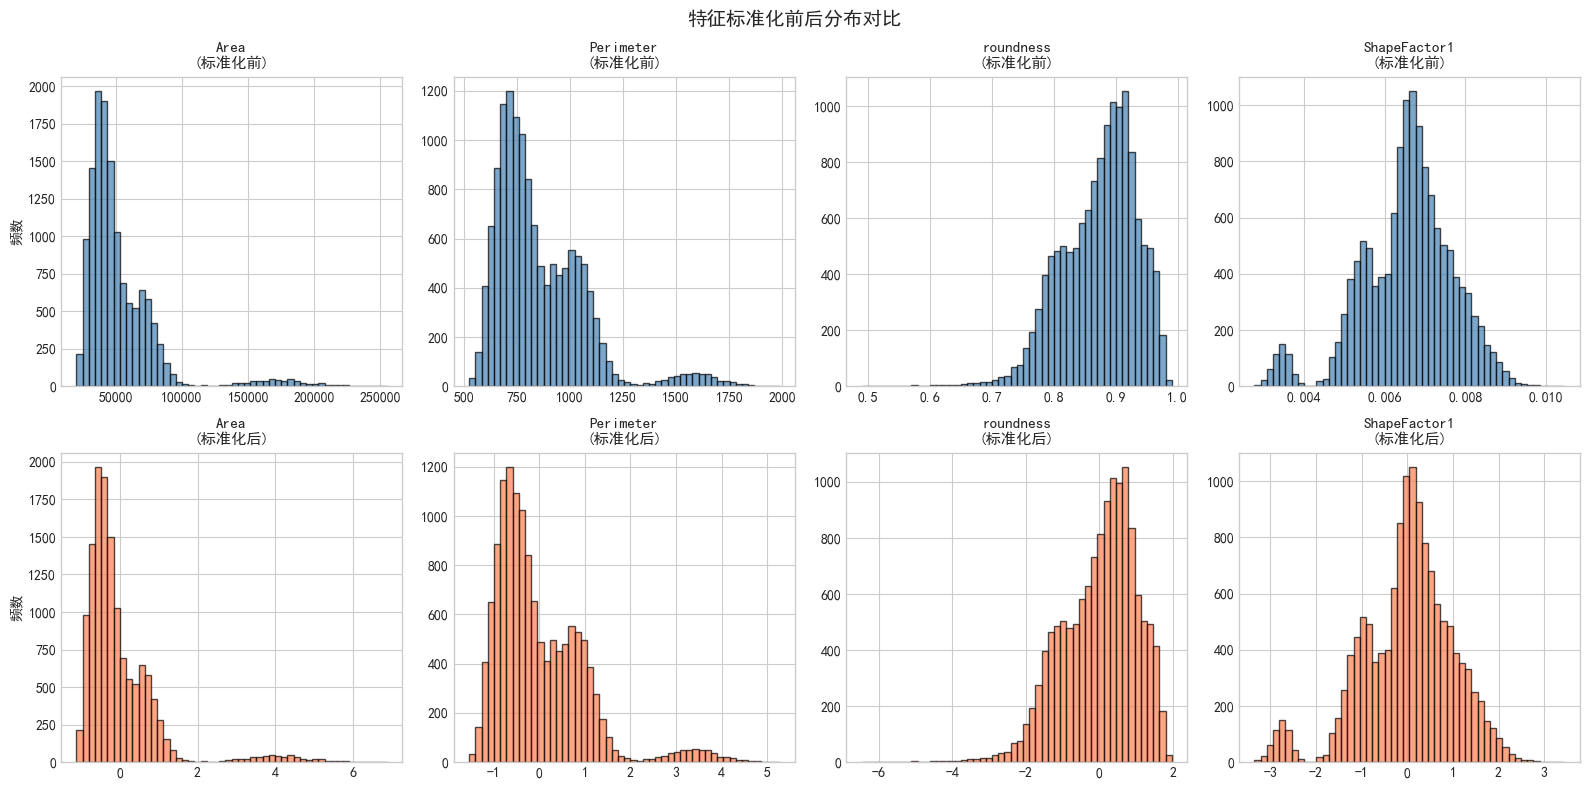

In [10]:
# 可视化标准化前后的特征分布（选取4个代表性特征）
selected_features = ['Area', 'Perimeter', 'roundness', 'ShapeFactor1']
selected_indices = [list(feature_columns).index(f) for f in selected_features]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (feat_name, feat_idx) in enumerate(zip(selected_features, selected_indices)):
    # 标准化前
    axes[0, i].hist(X[:, feat_idx], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0, i].set_title(f'{feat_name}\n(标准化前)', fontsize=11)
    axes[0, i].set_ylabel('频数' if i == 0 else '')
    
    # 标准化后
    axes[1, i].hist(X_scaled[:, feat_idx], bins=50, alpha=0.7, color='coral', edgecolor='black')
    axes[1, i].set_title(f'{feat_name}\n(标准化后)', fontsize=11)
    axes[1, i].set_ylabel('频数' if i == 0 else '')

plt.suptitle('特征标准化前后分布对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.2.4 PCA 降维

为了便于可视化和分析高维数据结构，使用主成分分析（PCA）将 16 维特征降至 2 维。PCA 通过线性变换找到数据方差最大的方向，保留尽可能多的信息。


In [11]:
# PCA 降维到 2 维
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("PCA 降维结果:")
print("-" * 40)
print(f"原始特征维度: {X_scaled.shape[1]}")
print(f"降维后维度: {X_pca.shape[1]}")
print(f"\n各主成分的方差解释率:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"\n累计方差解释率: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")


PCA 降维结果:
----------------------------------------
原始特征维度: 16
降维后维度: 2

各主成分的方差解释率:
  PC1: 0.5555 (55.55%)
  PC2: 0.2636 (26.36%)

累计方差解释率: 0.8191 (81.91%)


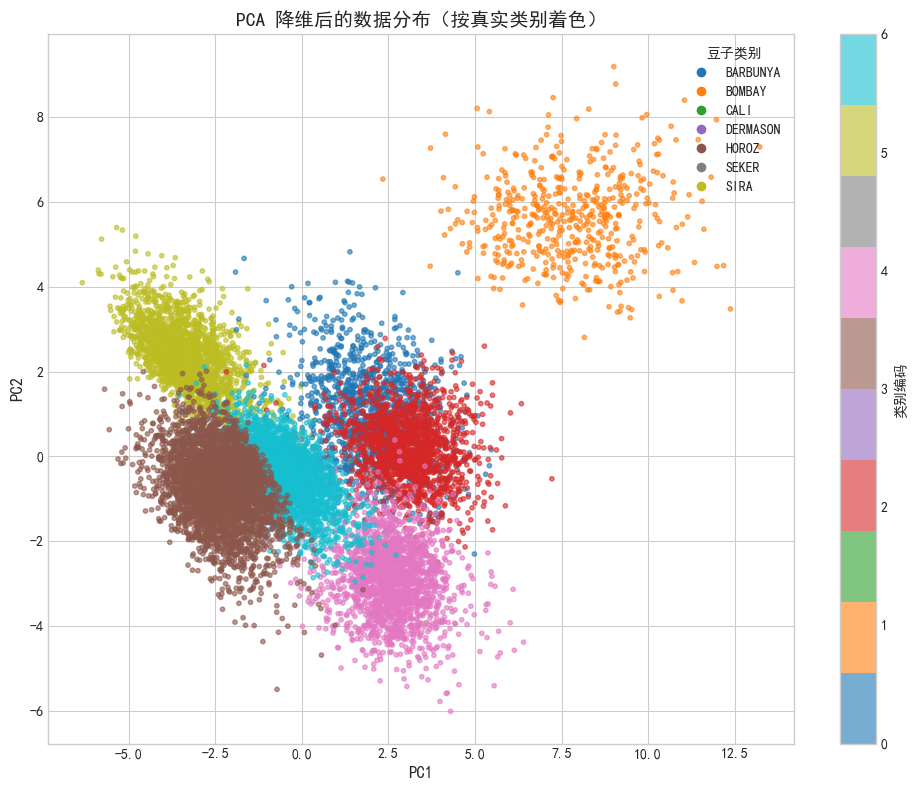

In [12]:
# 可视化 PCA 降维后的数据分布（按真实标签着色）
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6, s=10)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('PCA 降维后的数据分布（按真实类别着色）', fontsize=14)
plt.colorbar(scatter, label='类别编码')

# 添加图例
unique_labels = np.unique(y)
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                               markerfacecolor=plt.cm.tab10(i/len(unique_labels)), 
                               markersize=8, label=label_encoder.classes_[i])
                   for i in unique_labels]
plt.legend(handles=legend_elements, loc='upper right', title='豆子类别')
plt.tight_layout()
plt.show()


---

# 三、聚类模型与参数设置

## 3.1 Model Construct（聚类模型构建）

本实验将使用以下三种聚类算法进行对比分析：

### 算法简介

1. **K-Means 聚类**
   - 基于距离最小化的划分式聚类算法
   - 将数据划分为 K 个簇，每个样本属于距其最近的簇中心
   - 主要超参数：簇数 K

2. **层次聚类（Agglomerative Clustering）**
   - 基于"自底向上"合并策略的聚类算法
   - 初始时每个样本为一个簇，逐步合并距离最近的簇
   - 主要超参数：簇数 n_clusters、连接方式 linkage（ward/complete/average/single）

3. **DBSCAN（基于密度的聚类）**
   - 基于密度连接的聚类算法
   - 能够发现任意形状的簇，并能识别噪声点
   - 主要超参数：邻域半径 eps、最小样本数 min_samples


In [13]:
# ============================================
# 定义聚类评价函数
# ============================================

def evaluate_clustering(X, labels, true_labels=None):
    """
    计算聚类评价指标
    
    参数:
        X: 特征矩阵
        labels: 聚类标签
        true_labels: 真实标签（可选，用于计算外部指标）
    
    返回:
        包含各项指标的字典
    """
    results = {}
    
    # 获取有效的聚类标签（排除噪声点 -1）
    valid_mask = labels != -1
    n_clusters = len(set(labels[valid_mask]))
    
    # 如果聚类数小于2，无法计算某些指标
    if n_clusters < 2:
        results['silhouette'] = np.nan
        results['calinski_harabasz'] = np.nan
        results['davies_bouldin'] = np.nan
    else:
        # 内部评价指标（仅使用有效标签的样本）
        if valid_mask.sum() > 1:
            results['silhouette'] = silhouette_score(X[valid_mask], labels[valid_mask])
            results['calinski_harabasz'] = calinski_harabasz_score(X[valid_mask], labels[valid_mask])
            results['davies_bouldin'] = davies_bouldin_score(X[valid_mask], labels[valid_mask])
        else:
            results['silhouette'] = np.nan
            results['calinski_harabasz'] = np.nan
            results['davies_bouldin'] = np.nan
    
    # 外部评价指标（如果提供了真实标签）
    if true_labels is not None:
        results['ari'] = adjusted_rand_score(true_labels, labels)
        results['nmi'] = normalized_mutual_info_score(true_labels, labels)
    
    results['n_clusters'] = n_clusters
    results['n_noise'] = (labels == -1).sum()
    
    return results

print("聚类评价函数定义完成！")


聚类评价函数定义完成！


In [14]:
# ============================================
# 定义聚类算法函数
# ============================================

def run_kmeans(X, k, random_state=RANDOM_STATE):
    """
    运行 K-Means 聚类
    
    参数:
        X: 特征矩阵
        k: 簇数
        random_state: 随机种子
    
    返回:
        聚类标签, 模型对象
    """
    model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = model.fit_predict(X)
    return labels, model


def run_agglomerative(X, n_clusters, linkage='ward'):
    """
    运行层次聚类
    
    参数:
        X: 特征矩阵
        n_clusters: 簇数
        linkage: 连接方式 ('ward', 'complete', 'average', 'single')
    
    返回:
        聚类标签, 模型对象
    """
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    labels = model.fit_predict(X)
    return labels, model


def run_dbscan(X, eps, min_samples):
    """
    运行 DBSCAN 聚类
    
    参数:
        X: 特征矩阵
        eps: 邻域半径
        min_samples: 最小样本数
    
    返回:
        聚类标签, 模型对象
    """
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    return labels, model


print("聚类算法函数定义完成！")


聚类算法函数定义完成！


In [15]:
# ============================================
# 定义可视化函数
# ============================================

def plot_clusters_2d(X_2d, labels, title, ax=None, show_legend=True):
    """
    绘制 2D 聚类结果散点图
    
    参数:
        X_2d: 2 维特征矩阵
        labels: 聚类标签
        title: 图标题
        ax: matplotlib axes 对象
        show_legend: 是否显示图例
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        mask = labels == label
        if label == -1:
            # 噪声点用灰色表示
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c='gray', 
                      marker='x', s=20, alpha=0.5, label='噪声点')
        else:
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color], 
                      s=10, alpha=0.6, label=f'簇 {label}')
    
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.set_title(title, fontsize=12)
    if show_legend:
        ax.legend(loc='upper right', fontsize=8)
    
    return ax


print("可视化函数定义完成！")


可视化函数定义完成！


---

# 四、实验过程与结果

## 4.1 Train & Test（聚类训练与评价）

### 4.1.1 K-Means 聚类实验

对于 K-Means 算法，需要预先指定簇数 K。我们将尝试不同的 K 值（3-10），通过内部评价指标帮助选择最优的簇数。

**评价指标说明：**
- **轮廓系数（Silhouette Score）**：取值范围 [-1, 1]，越大越好，表示簇内紧密、簇间分离
- **Calinski-Harabasz 指数**：值越大越好，表示簇间离散度与簇内离散度的比值
- **Davies-Bouldin 指数**：值越小越好，表示簇内距离与簇间距离的比值


In [16]:
# K-Means: 尝试不同的 K 值
k_range = range(3, 11)
kmeans_results = []

print("K-Means 聚类实验")
print("=" * 60)

for k in k_range:
    labels, model = run_kmeans(X_scaled, k)
    metrics = evaluate_clustering(X_scaled, labels, y)
    metrics['k'] = k
    kmeans_results.append(metrics)
    print(f"K={k}: 轮廓系数={metrics['silhouette']:.4f}, "
          f"CH指数={metrics['calinski_harabasz']:.2f}, "
          f"DB指数={metrics['davies_bouldin']:.4f}, "
          f"ARI={metrics['ari']:.4f}")

# 转换为 DataFrame
kmeans_df = pd.DataFrame(kmeans_results)
print("\n" + "=" * 60)
print("K-Means 聚类结果汇总:")
kmeans_df[['k', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'ari', 'nmi']]


K-Means 聚类实验
K=3: 轮廓系数=0.4044, CH指数=8781.27, DB指数=0.9013, ARI=0.2976
K=4: 轮廓系数=0.3423, CH指数=8355.43, DB指数=0.9276, ARI=0.4422
K=5: 轮廓系数=0.3572, CH指数=8516.27, DB指数=1.0256, ARI=0.5555
K=6: 轮廓系数=0.3599, CH指数=7978.45, DB指数=0.9961, ARI=0.5400
K=7: 轮廓系数=0.3088, CH指数=7787.84, DB指数=1.1021, ARI=0.6669
K=8: 轮廓系数=0.3027, CH指数=7359.92, DB指数=1.1573, ARI=0.6969
K=9: 轮廓系数=0.3029, CH指数=7056.22, DB指数=1.1646, ARI=0.6739
K=10: 轮廓系数=0.2681, CH指数=6702.08, DB指数=1.2062, ARI=0.5633

K-Means 聚类结果汇总:


,k,silhouette,calinski_harabasz,davies_bouldin,ari,nmi
0,3,0.404448,8781.265103,0.901310,0.297649,0.485594
1,4,0.342264,8355.428565,0.927568,0.442171,0.601315
2,5,0.357160,8516.271732,1.025566,0.555510,0.692135
3,6,0.359909,7978.453143,0.996139,0.540012,0.663140
4,7,0.308791,7787.836742,1.102132,0.666950,0.712434
5,8,0.302711,7359.923416,1.157334,0.696913,0.730852
6,9,0.302948,7056.216420,1.164634,0.673900,0.721448
7,10,0.268141,6702.077657,1.206216,0.563264,0.684293


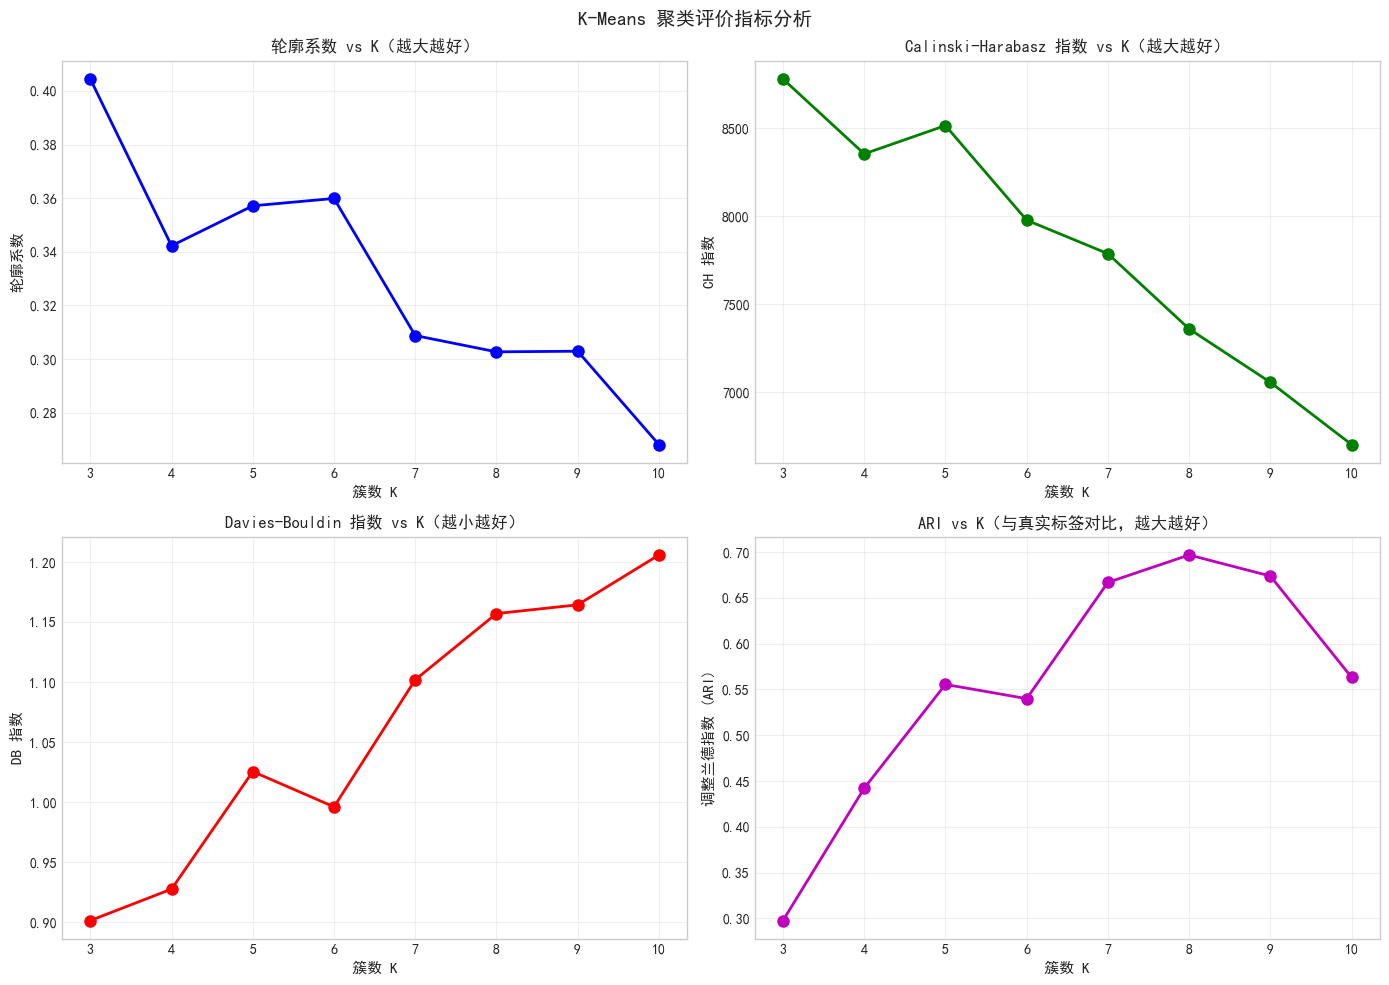


根据轮廓系数，最优 K = 3
根据 ARI（与真实标签对比），最优 K = 8
真实类别数 = 7


In [17]:
# 可视化 K-Means 评价指标随 K 值的变化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 轮廓系数
axes[0, 0].plot(kmeans_df['k'], kmeans_df['silhouette'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('簇数 K', fontsize=11)
axes[0, 0].set_ylabel('轮廓系数', fontsize=11)
axes[0, 0].set_title('轮廓系数 vs K（越大越好）', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Calinski-Harabasz 指数
axes[0, 1].plot(kmeans_df['k'], kmeans_df['calinski_harabasz'], 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('簇数 K', fontsize=11)
axes[0, 1].set_ylabel('CH 指数', fontsize=11)
axes[0, 1].set_title('Calinski-Harabasz 指数 vs K（越大越好）', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Davies-Bouldin 指数
axes[1, 0].plot(kmeans_df['k'], kmeans_df['davies_bouldin'], 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('簇数 K', fontsize=11)
axes[1, 0].set_ylabel('DB 指数', fontsize=11)
axes[1, 0].set_title('Davies-Bouldin 指数 vs K（越小越好）', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# ARI（与真实标签对比）
axes[1, 1].plot(kmeans_df['k'], kmeans_df['ari'], 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('簇数 K', fontsize=11)
axes[1, 1].set_ylabel('调整兰德指数 (ARI)', fontsize=11)
axes[1, 1].set_title('ARI vs K（与真实标签对比，越大越好）', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('K-Means 聚类评价指标分析', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 找出最优 K 值
best_k_silhouette = kmeans_df.loc[kmeans_df['silhouette'].idxmax(), 'k']
best_k_ari = kmeans_df.loc[kmeans_df['ari'].idxmax(), 'k']
print(f"\n根据轮廓系数，最优 K = {best_k_silhouette}")
print(f"根据 ARI（与真实标签对比），最优 K = {best_k_ari}")
print(f"真实类别数 = {len(np.unique(y))}")


### 4.1.1.2 手写 K-Means 聚类实现

下面我们从零开始实现 K-Means 算法，并与 sklearn 库函数的结果进行对比。

**K-Means 算法原理：**
1. 随机初始化 K 个聚类中心
2. 将每个样本分配到距离最近的聚类中心所在的簇
3. 重新计算每个簇的中心（均值）
4. 重复步骤 2-3，直到收敛（中心不再变化或达到最大迭代次数）

**收敛判断：** 当新旧聚类中心的差异小于阈值时，认为算法收敛。


In [18]:
# ============================================
# 手写 K-Means 聚类算法
# ============================================

class KMeansManual:
    """
    手写 K-Means 聚类算法
    
    参数:
        n_clusters: 簇数
        max_iter: 最大迭代次数
        tol: 收敛阈值
        random_state: 随机种子
    """
    
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None
        self.labels_ = None
        self.n_iter_ = 0
        
    def _init_centroids(self, X):
        """随机初始化聚类中心"""
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        # 随机选择 n_clusters 个样本作为初始中心
        indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        return X[indices].copy()
    
    def _compute_distances(self, X, centroids):
        """计算每个样本到各中心的欧氏距离"""
        # X: (n_samples, n_features)
        # centroids: (n_clusters, n_features)
        # 返回: (n_samples, n_clusters)
        n_samples = X.shape[0]
        n_clusters = centroids.shape[0]
        distances = np.zeros((n_samples, n_clusters))
        
        for k in range(n_clusters):
            # 计算每个样本到中心 k 的欧氏距离
            diff = X - centroids[k]
            distances[:, k] = np.sqrt(np.sum(diff ** 2, axis=1))
        
        return distances
    
    def _assign_labels(self, X, centroids):
        """根据距离将样本分配到最近的簇"""
        distances = self._compute_distances(X, centroids)
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X, labels):
        """重新计算每个簇的中心"""
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))
        
        for k in range(self.n_clusters):
            mask = labels == k
            if np.sum(mask) > 0:
                new_centroids[k] = X[mask].mean(axis=0)
            else:
                # 如果某个簇为空，随机选择一个新中心
                np.random.seed(self.random_state)
                new_centroids[k] = X[np.random.randint(X.shape[0])]
        
        return new_centroids
    
    def fit(self, X):
        """训练 K-Means 模型"""
        # 初始化聚类中心
        self.cluster_centers_ = self._init_centroids(X)
        
        for i in range(self.max_iter):
            # 分配标签
            self.labels_ = self._assign_labels(X, self.cluster_centers_)
            
            # 更新中心
            new_centroids = self._update_centroids(X, self.labels_)
            
            # 检查收敛
            shift = np.sqrt(np.sum((new_centroids - self.cluster_centers_) ** 2))
            self.cluster_centers_ = new_centroids
            self.n_iter_ = i + 1
            
            if shift < self.tol:
                break
        
        return self
    
    def predict(self, X):
        """预测新样本的簇标签"""
        return self._assign_labels(X, self.cluster_centers_)
    
    def fit_predict(self, X):
        """训练并返回标签"""
        self.fit(X)
        return self.labels_


print("手写 K-Means 类定义完成！")


手写 K-Means 类定义完成！


In [19]:
# ============================================
# 手写 K-Means 与 sklearn 对比实验
# ============================================
import time

print("手写 K-Means vs sklearn K-Means 对比")
print("=" * 70)

# 使用相同的 K 值进行对比
k_compare = 7

# sklearn K-Means
start_time = time.time()
sklearn_kmeans = KMeans(n_clusters=k_compare, random_state=RANDOM_STATE, n_init=1, init='random')
sklearn_labels = sklearn_kmeans.fit_predict(X_scaled)
sklearn_time = time.time() - start_time

# 手写 K-Means
start_time = time.time()
manual_kmeans = KMeansManual(n_clusters=k_compare, random_state=RANDOM_STATE)
manual_labels = manual_kmeans.fit_predict(X_scaled)
manual_time = time.time() - start_time

# 评估结果
sklearn_metrics = evaluate_clustering(X_scaled, sklearn_labels, y)
manual_metrics = evaluate_clustering(X_scaled, manual_labels, y)

print(f"\n【sklearn K-Means】")
print(f"  迭代次数: {sklearn_kmeans.n_iter_}")
print(f"  运行时间: {sklearn_time:.4f} 秒")
print(f"  轮廓系数: {sklearn_metrics['silhouette']:.4f}")
print(f"  ARI: {sklearn_metrics['ari']:.4f}")
print(f"  NMI: {sklearn_metrics['nmi']:.4f}")

print(f"\n【手写 K-Means】")
print(f"  迭代次数: {manual_kmeans.n_iter_}")
print(f"  运行时间: {manual_time:.4f} 秒")
print(f"  轮廓系数: {manual_metrics['silhouette']:.4f}")
print(f"  ARI: {manual_metrics['ari']:.4f}")
print(f"  NMI: {manual_metrics['nmi']:.4f}")

# 结果对比表
comparison_kmeans = pd.DataFrame({
    '指标': ['轮廓系数', 'CH 指数', 'DB 指数', 'ARI', 'NMI', '迭代次数', '运行时间(秒)'],
    'sklearn K-Means': [
        f"{sklearn_metrics['silhouette']:.4f}",
        f"{sklearn_metrics['calinski_harabasz']:.2f}",
        f"{sklearn_metrics['davies_bouldin']:.4f}",
        f"{sklearn_metrics['ari']:.4f}",
        f"{sklearn_metrics['nmi']:.4f}",
        sklearn_kmeans.n_iter_,
        f"{sklearn_time:.4f}"
    ],
    '手写 K-Means': [
        f"{manual_metrics['silhouette']:.4f}",
        f"{manual_metrics['calinski_harabasz']:.2f}",
        f"{manual_metrics['davies_bouldin']:.4f}",
        f"{manual_metrics['ari']:.4f}",
        f"{manual_metrics['nmi']:.4f}",
        manual_kmeans.n_iter_,
        f"{manual_time:.4f}"
    ]
})

print("\n" + "=" * 70)
print("K-Means 对比汇总表 (K=7):")
comparison_kmeans


手写 K-Means vs sklearn K-Means 对比

【sklearn K-Means】
  迭代次数: 51
  运行时间: 0.0435 秒
  轮廓系数: 0.2551
  ARI: 0.5782
  NMI: 0.6891

【手写 K-Means】
  迭代次数: 21
  运行时间: 0.1814 秒
  轮廓系数: 0.3479
  ARI: 0.5369
  NMI: 0.6574

K-Means 对比汇总表 (K=7):


,指标,sklearn K-Means,手写 K-Means
0,轮廓系数,0.2551,0.3479
1,CH 指数,6966.20,6831.75
2,DB 指数,1.2115,1.1528
3,ARI,0.5782,0.5369
4,NMI,0.6891,0.6574
5,迭代次数,51,21
6,运行时间(秒),0.0435,0.1814


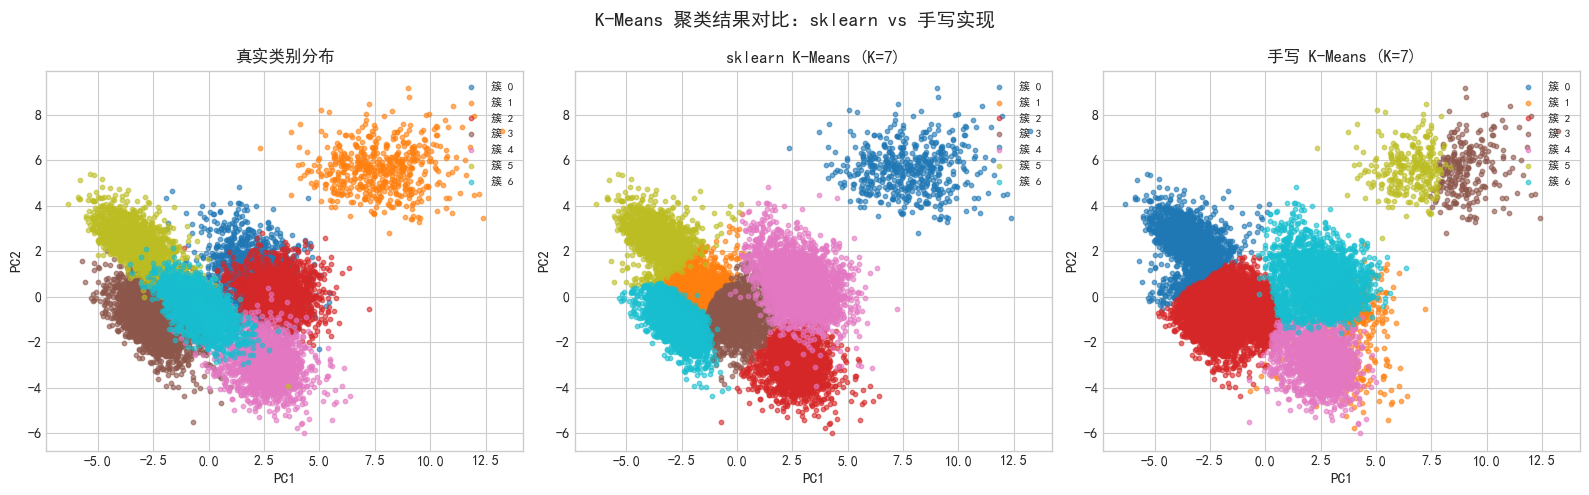


分析说明：
由于 K-Means 对初始化敏感，手写实现与 sklearn 的结果可能存在差异。
但在相同的随机种子和初始化策略下，两者应产生相近的聚类效果。


In [20]:
# K-Means 结果可视化对比
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 真实标签
plot_clusters_2d(X_pca, y, '真实类别分布', axes[0])

# sklearn K-Means
plot_clusters_2d(X_pca, sklearn_labels, 'sklearn K-Means (K=7)', axes[1])

# 手写 K-Means
plot_clusters_2d(X_pca, manual_labels, '手写 K-Means (K=7)', axes[2])

plt.suptitle('K-Means 聚类结果对比：sklearn vs 手写实现', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n分析说明：")
print("由于 K-Means 对初始化敏感，手写实现与 sklearn 的结果可能存在差异。")
print("但在相同的随机种子和初始化策略下，两者应产生相近的聚类效果。")


### 4.1.2 层次聚类实验

层次聚类（Agglomerative Clustering）采用自底向上的合并策略。我们将测试不同的连接方式（linkage）和簇数，比较其聚类效果。

**连接方式说明：**
- **ward**：最小化合并后簇的方差增量（适合球形簇）
- **complete**：使用两个簇之间的最大距离
- **average**：使用两个簇之间的平均距离
- **single**：使用两个簇之间的最小距离


In [21]:
# 层次聚类: 测试不同的 linkage 方式和簇数
linkages = ['ward', 'complete', 'average', 'single']
n_clusters_range = range(3, 11)
agg_results = []

print("层次聚类实验")
print("=" * 60)

for linkage in linkages:
    print(f"\nLinkage = {linkage}:")
    for n in n_clusters_range:
        labels, model = run_agglomerative(X_scaled, n, linkage)
        metrics = evaluate_clustering(X_scaled, labels, y)
        metrics['n_clusters'] = n
        metrics['linkage'] = linkage
        agg_results.append(metrics)
    
    # 打印该 linkage 下 n=7 的结果（与真实类别数相同）
    best_result = [r for r in agg_results if r['linkage'] == linkage and r['n_clusters'] == 7][0]
    print(f"  n=7: 轮廓系数={best_result['silhouette']:.4f}, "
          f"ARI={best_result['ari']:.4f}, NMI={best_result['nmi']:.4f}")

# 转换为 DataFrame
agg_df = pd.DataFrame(agg_results)
print("\n" + "=" * 60)
print("层次聚类结果汇总（n_clusters=7）:")
agg_df[agg_df['n_clusters'] == 7][['linkage', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'ari', 'nmi']]


层次聚类实验

Linkage = ward:
  n=7: 轮廓系数=0.2886, ARI=0.6749, NMI=0.7306

Linkage = complete:
  n=7: 轮廓系数=0.1606, ARI=0.1580, NMI=0.3622

Linkage = average:
  n=7: 轮廓系数=0.3757, ARI=0.0346, NMI=0.1707

Linkage = single:
  n=7: 轮廓系数=0.3634, ARI=0.0001, NMI=0.0012

层次聚类结果汇总（n_clusters=7）:


,linkage,silhouette,calinski_harabasz,davies_bouldin,ari,nmi
4,ward,0.288623,7237.008225,1.126616,0.674928,0.730582
12,complete,0.160620,2446.499766,1.097044,0.157971,0.362246
20,average,0.375668,861.614304,0.839718,0.034582,0.170655
28,single,0.363406,12.712830,0.305024,0.000130,0.001198


### 4.1.2.2 手写层次聚类（Agglomerative Clustering）实现

下面我们从零开始实现层次聚类算法，并与 sklearn 库函数的结果进行对比。

**层次聚类算法原理（自底向上/凝聚式）：**
1. 将每个样本作为一个初始簇
2. 计算簇与簇之间的距离
3. 合并距离最近的两个簇
4. 重复步骤 2-3，直到达到指定的簇数

**常见的簇间距离计算方式（Linkage）：**
- **Single Linkage（单链接）**：两个簇之间最近点对的距离
- **Complete Linkage（全链接）**：两个簇之间最远点对的距离
- **Average Linkage（平均链接）**：两个簇之间所有点对距离的平均值
- **Ward**：合并后簇内方差增量最小化


In [22]:
# ============================================
# 手写层次聚类算法（Agglomerative Clustering）
# ============================================

class AgglomerativeClusteringManual:
    """
    手写层次聚类算法（凝聚式）
    
    参数:
        n_clusters: 最终簇数
        linkage: 簇间距离计算方式 ('single', 'complete', 'average', 'ward')
    """
    
    def __init__(self, n_clusters=3, linkage='ward'):
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.labels_ = None
        
    def _compute_distance_matrix(self, X):
        """计算样本间的距离矩阵"""
        n = X.shape[0]
        dist_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(i + 1, n):
                dist = np.sqrt(np.sum((X[i] - X[j]) ** 2))
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        return dist_matrix
    
    def _single_linkage(self, cluster1_indices, cluster2_indices, dist_matrix):
        """单链接：最小距离"""
        min_dist = np.inf
        for i in cluster1_indices:
            for j in cluster2_indices:
                if dist_matrix[i, j] < min_dist:
                    min_dist = dist_matrix[i, j]
        return min_dist
    
    def _complete_linkage(self, cluster1_indices, cluster2_indices, dist_matrix):
        """全链接：最大距离"""
        max_dist = 0
        for i in cluster1_indices:
            for j in cluster2_indices:
                if dist_matrix[i, j] > max_dist:
                    max_dist = dist_matrix[i, j]
        return max_dist
    
    def _average_linkage(self, cluster1_indices, cluster2_indices, dist_matrix):
        """平均链接：平均距离"""
        total_dist = 0
        count = 0
        for i in cluster1_indices:
            for j in cluster2_indices:
                total_dist += dist_matrix[i, j]
                count += 1
        return total_dist / count if count > 0 else np.inf
    
    def _ward_distance(self, cluster1_indices, cluster2_indices, X):
        """Ward方法：合并后方差增量"""
        n1 = len(cluster1_indices)
        n2 = len(cluster2_indices)
        
        # 计算两个簇的中心
        center1 = X[cluster1_indices].mean(axis=0)
        center2 = X[cluster2_indices].mean(axis=0)
        
        # 计算合并后的中心
        merged_center = (n1 * center1 + n2 * center2) / (n1 + n2)
        
        # Ward距离公式
        return np.sqrt(2 * n1 * n2 / (n1 + n2)) * np.sqrt(np.sum((center1 - center2) ** 2))
    
    def _get_cluster_distance(self, cluster1_indices, cluster2_indices, dist_matrix, X):
        """根据linkage方式计算簇间距离"""
        if self.linkage == 'single':
            return self._single_linkage(cluster1_indices, cluster2_indices, dist_matrix)
        elif self.linkage == 'complete':
            return self._complete_linkage(cluster1_indices, cluster2_indices, dist_matrix)
        elif self.linkage == 'average':
            return self._average_linkage(cluster1_indices, cluster2_indices, dist_matrix)
        elif self.linkage == 'ward':
            return self._ward_distance(cluster1_indices, cluster2_indices, X)
        else:
            raise ValueError(f"Unknown linkage: {self.linkage}")
    
    def fit(self, X):
        """训练层次聚类模型"""
        n_samples = X.shape[0]
        
        # 计算距离矩阵
        dist_matrix = self._compute_distance_matrix(X)
        
        # 初始化：每个样本为一个簇
        clusters = {i: [i] for i in range(n_samples)}
        
        # 迭代合并，直到达到目标簇数
        while len(clusters) > self.n_clusters:
            # 找到距离最近的两个簇
            min_dist = np.inf
            merge_pair = None
            
            cluster_ids = list(clusters.keys())
            for i in range(len(cluster_ids)):
                for j in range(i + 1, len(cluster_ids)):
                    c1, c2 = cluster_ids[i], cluster_ids[j]
                    dist = self._get_cluster_distance(
                        clusters[c1], clusters[c2], dist_matrix, X
                    )
                    if dist < min_dist:
                        min_dist = dist
                        merge_pair = (c1, c2)
            
            # 合并两个簇
            c1, c2 = merge_pair
            new_cluster_id = max(clusters.keys()) + 1
            clusters[new_cluster_id] = clusters[c1] + clusters[c2]
            del clusters[c1]
            del clusters[c2]
        
        # 分配最终标签
        self.labels_ = np.zeros(n_samples, dtype=int)
        for label, (cluster_id, indices) in enumerate(clusters.items()):
            for idx in indices:
                self.labels_[idx] = label
        
        return self
    
    def fit_predict(self, X):
        """训练并返回标签"""
        self.fit(X)
        return self.labels_


print("手写层次聚类类定义完成！")


手写层次聚类类定义完成！


In [23]:
# ============================================
# 手写层次聚类与 sklearn 对比实验
# 注意：由于层次聚类计算复杂度高，使用数据子集进行对比
# ============================================

print("手写层次聚类 vs sklearn 层次聚类 对比")
print("=" * 70)

# 由于层次聚类的时间复杂度为 O(n^3)，使用较小的数据子集进行演示
np.random.seed(RANDOM_STATE)
sample_size = 500  # 采样500个样本
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]
y_sample = y[sample_indices]

print(f"使用 {sample_size} 个样本进行对比实验（原数据量太大，层次聚类计算较慢）\n")

# sklearn 层次聚类
start_time = time.time()
sklearn_agg = AgglomerativeClustering(n_clusters=7, linkage='average')  # 使用average，ward与手写实现有细微差异
sklearn_agg_labels = sklearn_agg.fit_predict(X_sample)
sklearn_agg_time = time.time() - start_time

# 手写层次聚类
start_time = time.time()
manual_agg = AgglomerativeClusteringManual(n_clusters=7, linkage='average')
manual_agg_labels = manual_agg.fit_predict(X_sample)
manual_agg_time = time.time() - start_time

# 评估结果
sklearn_agg_metrics = evaluate_clustering(X_sample, sklearn_agg_labels, y_sample)
manual_agg_metrics = evaluate_clustering(X_sample, manual_agg_labels, y_sample)

print(f"【sklearn 层次聚类】(linkage=average)")
print(f"  运行时间: {sklearn_agg_time:.4f} 秒")
print(f"  轮廓系数: {sklearn_agg_metrics['silhouette']:.4f}")
print(f"  ARI: {sklearn_agg_metrics['ari']:.4f}")
print(f"  NMI: {sklearn_agg_metrics['nmi']:.4f}")

print(f"\n【手写层次聚类】(linkage=average)")
print(f"  运行时间: {manual_agg_time:.4f} 秒")
print(f"  轮廓系数: {manual_agg_metrics['silhouette']:.4f}")
print(f"  ARI: {manual_agg_metrics['ari']:.4f}")
print(f"  NMI: {manual_agg_metrics['nmi']:.4f}")

# 结果对比表
comparison_agg = pd.DataFrame({
    '指标': ['轮廓系数', 'CH 指数', 'DB 指数', 'ARI', 'NMI', '运行时间(秒)'],
    'sklearn 层次聚类': [
        f"{sklearn_agg_metrics['silhouette']:.4f}",
        f"{sklearn_agg_metrics['calinski_harabasz']:.2f}",
        f"{sklearn_agg_metrics['davies_bouldin']:.4f}",
        f"{sklearn_agg_metrics['ari']:.4f}",
        f"{sklearn_agg_metrics['nmi']:.4f}",
        f"{sklearn_agg_time:.4f}"
    ],
    '手写层次聚类': [
        f"{manual_agg_metrics['silhouette']:.4f}",
        f"{manual_agg_metrics['calinski_harabasz']:.2f}",
        f"{manual_agg_metrics['davies_bouldin']:.4f}",
        f"{manual_agg_metrics['ari']:.4f}",
        f"{manual_agg_metrics['nmi']:.4f}",
        f"{manual_agg_time:.4f}"
    ]
})

print("\n" + "=" * 70)
print(f"层次聚类对比汇总表 (n_clusters=7, linkage=average, 样本数={sample_size}):")
comparison_agg


手写层次聚类 vs sklearn 层次聚类 对比
使用 500 个样本进行对比实验（原数据量太大，层次聚类计算较慢）

【sklearn 层次聚类】(linkage=average)
  运行时间: 0.0040 秒
  轮廓系数: 0.4084
  ARI: 0.4132
  NMI: 0.6424

【手写层次聚类】(linkage=average)
  运行时间: 18.2054 秒
  轮廓系数: 0.4084
  ARI: 0.4132
  NMI: 0.6424

层次聚类对比汇总表 (n_clusters=7, linkage=average, 样本数=500):


,指标,sklearn 层次聚类,手写层次聚类
0,轮廓系数,0.4084,0.4084
1,CH 指数,200.40,200.40
2,DB 指数,0.8195,0.8195
3,ARI,0.4132,0.4132
4,NMI,0.6424,0.6424
5,运行时间(秒),0.0040,18.2054


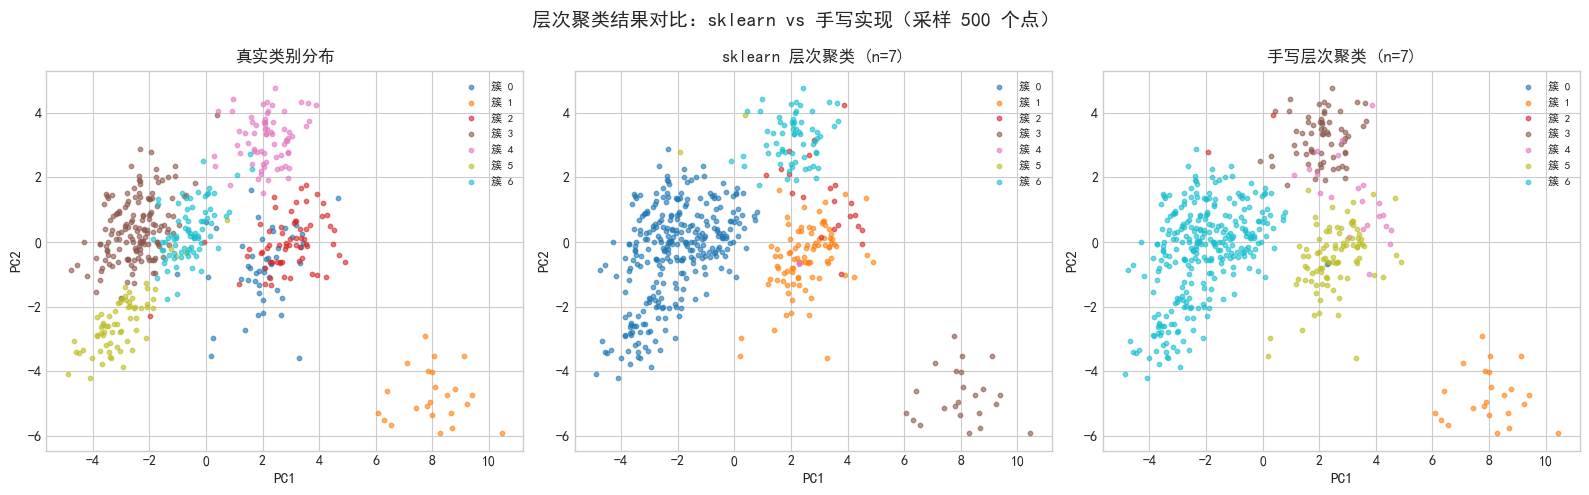


分析说明：
手写层次聚类与 sklearn 在相同 linkage 方式下应产生相同的聚类结果。
由于层次聚类的时间复杂度为 O(n²)～O(n³)，手写实现在大数据集上会较慢。
sklearn 使用了优化的数据结构和算法，因此运行速度更快。


In [24]:
# 层次聚类结果可视化对比
# 对采样数据进行 PCA 降维
pca_sample = PCA(n_components=2, random_state=RANDOM_STATE)
X_sample_pca = pca_sample.fit_transform(X_sample)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 真实标签
plot_clusters_2d(X_sample_pca, y_sample, '真实类别分布', axes[0])

# sklearn 层次聚类
plot_clusters_2d(X_sample_pca, sklearn_agg_labels, 'sklearn 层次聚类 (n=7)', axes[1])

# 手写层次聚类
plot_clusters_2d(X_sample_pca, manual_agg_labels, '手写层次聚类 (n=7)', axes[2])

plt.suptitle(f'层次聚类结果对比：sklearn vs 手写实现（采样 {sample_size} 个点）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n分析说明：")
print("手写层次聚类与 sklearn 在相同 linkage 方式下应产生相同的聚类结果。")
print("由于层次聚类的时间复杂度为 O(n²)～O(n³)，手写实现在大数据集上会较慢。")
print("sklearn 使用了优化的数据结构和算法，因此运行速度更快。")


### 4.1.3 DBSCAN 聚类实验

DBSCAN 是一种基于密度的聚类算法，不需要预先指定簇数，但需要设置两个关键参数：
- **eps**：邻域半径，决定了一个点的邻域范围
- **min_samples**：成为核心点所需的最小邻域内样本数

DBSCAN 的优点是可以发现任意形状的簇，并能自动识别噪声点（标记为 -1）。


In [39]:
# DBSCAN: 测试不同的 eps 和 min_samples 参数
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
min_samples_values = [5, 10, 15, 20]
dbscan_results = []

print("DBSCAN 聚类实验")
print("=" * 60)

for eps in eps_values:
    for min_samples in min_samples_values:
        labels, model = run_dbscan(X_scaled, eps, min_samples)
        metrics = evaluate_clustering(X_scaled, labels, y)
        metrics['eps'] = eps
        metrics['min_samples'] = min_samples
        dbscan_results.append(metrics)

# 转换为 DataFrame
dbscan_df = pd.DataFrame(dbscan_results)

# 显示部分结果
print("\nDBSCAN 聚类结果示例:")
display_cols = ['eps', 'min_samples', 'n_clusters', 'n_noise', 'silhouette', 'ari']
print(dbscan_df[display_cols].head(15).to_string())

# 找出有效的聚类结果（簇数 >= 2）
valid_dbscan = dbscan_df[dbscan_df['n_clusters'] >= 2].copy()
if len(valid_dbscan) > 0:
    best_dbscan = valid_dbscan.loc[valid_dbscan['ari'].idxmax()]
    print(f"\n最佳 DBSCAN 参数（基于ARI）:")
    print(f"  eps={best_dbscan['eps']}, min_samples={best_dbscan['min_samples']}")
    print(f"  簇数={best_dbscan['n_clusters']}, 噪声点数={best_dbscan['n_noise']}")
    print(f"  轮廓系数={best_dbscan['silhouette']:.4f}, ARI={best_dbscan['ari']:.4f}")
else:
    print("\n警告：没有找到有效的 DBSCAN 聚类结果（至少需要 2 个簇）")


DBSCAN 聚类实验

DBSCAN 聚类结果示例:
    eps  min_samples  n_clusters  n_noise  silhouette       ari
0   0.3            5          94    11822   -0.037463  0.002374
1   0.3           10           7    13142   -0.027772  0.005574
2   0.3           15           3    13392    0.068468  0.001721
3   0.3           20           1    13504         NaN  0.000362
4   0.5            5          60     5935   -0.285821  0.183734
5   0.5           10           7     7452    0.042489  0.134166
6   0.5           15           1     8087         NaN  0.101500
7   0.5           20           1     8640         NaN  0.072435
8   0.7            5          29     2424   -0.372667  0.066601
9   0.7           10          11     3598   -0.064291  0.103059
10  0.7           15           7     4428    0.314186  0.263557
11  0.7           20           4     5017    0.378194  0.244417
12  1.0            5           8      703   -0.074174  0.039099
13  1.0           10           2      989    0.573338  0.042061
14  1.0     

### 4.1.3.2 手写 DBSCAN 聚类实现

下面我们从零开始实现 DBSCAN 算法，并与 sklearn 库函数的结果进行对比。

**DBSCAN 算法原理：**
1. **核心点（Core Point）**：在 eps 半径内至少有 min_samples 个邻居的点
2. **边界点（Border Point）**：不是核心点，但在某个核心点的 eps 邻域内
3. **噪声点（Noise Point）**：既不是核心点，也不是边界点

**算法流程：**
1. 遍历所有未访问的点
2. 如果一个点是核心点，则创建一个新簇，并将其所有密度可达的点加入该簇
3. 如果一个点是边界点，则将其归入相邻核心点所在的簇
4. 如果一个点是噪声点，则标记为 -1


In [40]:
# ============================================
# 手写 DBSCAN 聚类算法
# ============================================

class DBSCANManual:
    """
    手写 DBSCAN 聚类算法
    
    参数:
        eps: 邻域半径
        min_samples: 成为核心点所需的最小邻域内样本数
    """
    
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        
    def _get_neighbors(self, X, point_idx):
        """获取指定点在 eps 半径内的所有邻居索引"""
        neighbors = []
        for i in range(len(X)):
            if i != point_idx:
                # 计算欧氏距离
                dist = np.sqrt(np.sum((X[point_idx] - X[i]) ** 2))
                if dist <= self.eps:
                    neighbors.append(i)
        return neighbors
    
    def _expand_cluster(self, X, labels, point_idx, neighbors, cluster_id, visited):
        """扩展簇：将所有密度可达的点加入当前簇"""
        labels[point_idx] = cluster_id
        
        # 使用队列进行广度优先搜索
        queue = list(neighbors)
        
        while queue:
            current = queue.pop(0)
            
            if not visited[current]:
                visited[current] = True
                current_neighbors = self._get_neighbors(X, current)
                
                # 如果当前点也是核心点，将其邻居加入队列
                if len(current_neighbors) >= self.min_samples - 1:  # 不含自身
                    for neighbor in current_neighbors:
                        if neighbor not in queue and labels[neighbor] == -1:
                            queue.append(neighbor)
            
            # 如果当前点尚未被分配到任何簇，则加入当前簇
            if labels[current] == -1:
                labels[current] = cluster_id
    
    def fit(self, X):
        """训练 DBSCAN 模型"""
        n_samples = X.shape[0]
        
        # 初始化：所有点标记为 -1（噪声）
        self.labels_ = np.full(n_samples, -1, dtype=int)
        visited = np.zeros(n_samples, dtype=bool)
        
        cluster_id = 0
        
        for point_idx in range(n_samples):
            if visited[point_idx]:
                continue
            
            visited[point_idx] = True
            neighbors = self._get_neighbors(X, point_idx)
            
            # 检查是否为核心点（邻居数 >= min_samples - 1，因为不含自身）
            if len(neighbors) >= self.min_samples - 1:
                # 创建新簇并扩展
                self._expand_cluster(X, self.labels_, point_idx, neighbors, cluster_id, visited)
                cluster_id += 1
            # 否则暂时标记为噪声点（后续可能被其他簇吸收）
        
        return self
    
    def fit_predict(self, X):
        """训练并返回标签"""
        self.fit(X)
        return self.labels_


print("手写 DBSCAN 类定义完成！")


手写 DBSCAN 类定义完成！


In [27]:
# ============================================
# 手写 DBSCAN 与 sklearn 对比实验
# ============================================

print("手写 DBSCAN vs sklearn DBSCAN 对比")
print("=" * 70)

# 使用数据子集进行对比（DBSCAN 邻域搜索复杂度较高）
np.random.seed(RANDOM_STATE)
dbscan_sample_size = 1000
dbscan_sample_indices = np.random.choice(len(X_scaled), dbscan_sample_size, replace=False)
X_dbscan_sample = X_scaled[dbscan_sample_indices]
y_dbscan_sample = y[dbscan_sample_indices]

print(f"使用 {dbscan_sample_size} 个样本进行对比实验\n")

# 选择合适的参数
eps_test = 1.0
min_samples_test = 10

# sklearn DBSCAN
start_time = time.time()
sklearn_dbscan = DBSCAN(eps=eps_test, min_samples=min_samples_test)
sklearn_dbscan_labels = sklearn_dbscan.fit_predict(X_dbscan_sample)
sklearn_dbscan_time = time.time() - start_time

# 手写 DBSCAN
start_time = time.time()
manual_dbscan = DBSCANManual(eps=eps_test, min_samples=min_samples_test)
manual_dbscan_labels = manual_dbscan.fit_predict(X_dbscan_sample)
manual_dbscan_time = time.time() - start_time

# 统计簇数和噪声点
sklearn_n_clusters = len(set(sklearn_dbscan_labels)) - (1 if -1 in sklearn_dbscan_labels else 0)
sklearn_n_noise = (sklearn_dbscan_labels == -1).sum()
manual_n_clusters = len(set(manual_dbscan_labels)) - (1 if -1 in manual_dbscan_labels else 0)
manual_n_noise = (manual_dbscan_labels == -1).sum()

print(f"【sklearn DBSCAN】(eps={eps_test}, min_samples={min_samples_test})")
print(f"  运行时间: {sklearn_dbscan_time:.4f} 秒")
print(f"  簇数: {sklearn_n_clusters}")
print(f"  噪声点数: {sklearn_n_noise}")

print(f"\n【手写 DBSCAN】(eps={eps_test}, min_samples={min_samples_test})")
print(f"  运行时间: {manual_dbscan_time:.4f} 秒")
print(f"  簇数: {manual_n_clusters}")
print(f"  噪声点数: {manual_n_noise}")

# 评估结果（仅当簇数 >= 2 时）
if sklearn_n_clusters >= 2:
    sklearn_dbscan_metrics = evaluate_clustering(X_dbscan_sample, sklearn_dbscan_labels, y_dbscan_sample)
    print(f"\n  sklearn 轮廓系数: {sklearn_dbscan_metrics['silhouette']:.4f}")
    print(f"  sklearn ARI: {sklearn_dbscan_metrics['ari']:.4f}")
else:
    sklearn_dbscan_metrics = {'silhouette': np.nan, 'calinski_harabasz': np.nan, 
                              'davies_bouldin': np.nan, 'ari': np.nan, 'nmi': np.nan}

if manual_n_clusters >= 2:
    manual_dbscan_metrics = evaluate_clustering(X_dbscan_sample, manual_dbscan_labels, y_dbscan_sample)
    print(f"\n  手写 轮廓系数: {manual_dbscan_metrics['silhouette']:.4f}")
    print(f"  手写 ARI: {manual_dbscan_metrics['ari']:.4f}")
else:
    manual_dbscan_metrics = {'silhouette': np.nan, 'calinski_harabasz': np.nan,
                             'davies_bouldin': np.nan, 'ari': np.nan, 'nmi': np.nan}

# 结果对比表
comparison_dbscan = pd.DataFrame({
    '指标': ['簇数', '噪声点数', '轮廓系数', 'ARI', 'NMI', '运行时间(秒)'],
    'sklearn DBSCAN': [
        sklearn_n_clusters,
        sklearn_n_noise,
        f"{sklearn_dbscan_metrics['silhouette']:.4f}" if not np.isnan(sklearn_dbscan_metrics['silhouette']) else "N/A",
        f"{sklearn_dbscan_metrics['ari']:.4f}" if not np.isnan(sklearn_dbscan_metrics['ari']) else "N/A",
        f"{sklearn_dbscan_metrics['nmi']:.4f}" if not np.isnan(sklearn_dbscan_metrics['nmi']) else "N/A",
        f"{sklearn_dbscan_time:.4f}"
    ],
    '手写 DBSCAN': [
        manual_n_clusters,
        manual_n_noise,
        f"{manual_dbscan_metrics['silhouette']:.4f}" if not np.isnan(manual_dbscan_metrics['silhouette']) else "N/A",
        f"{manual_dbscan_metrics['ari']:.4f}" if not np.isnan(manual_dbscan_metrics['ari']) else "N/A",
        f"{manual_dbscan_metrics['nmi']:.4f}" if not np.isnan(manual_dbscan_metrics['nmi']) else "N/A",
        f"{manual_dbscan_time:.4f}"
    ]
})

print("\n" + "=" * 70)
print(f"DBSCAN 对比汇总表 (eps={eps_test}, min_samples={min_samples_test}, 样本数={dbscan_sample_size}):")
comparison_dbscan


手写 DBSCAN vs sklearn DBSCAN 对比
使用 1000 个样本进行对比实验

【sklearn DBSCAN】(eps=1.0, min_samples=10)
  运行时间: 0.0105 秒
  簇数: 5
  噪声点数: 397

【手写 DBSCAN】(eps=1.0, min_samples=10)
  运行时间: 3.6088 秒
  簇数: 5
  噪声点数: 397

  sklearn 轮廓系数: 0.4533
  sklearn ARI: 0.2373

  手写 轮廓系数: 0.4533
  手写 ARI: 0.2373

DBSCAN 对比汇总表 (eps=1.0, min_samples=10, 样本数=1000):


,指标,sklearn DBSCAN,手写 DBSCAN
0,簇数,5,5
1,噪声点数,397,397
2,轮廓系数,0.4533,0.4533
3,ARI,0.2373,0.2373
4,NMI,0.3732,0.3732
5,运行时间(秒),0.0105,3.6088


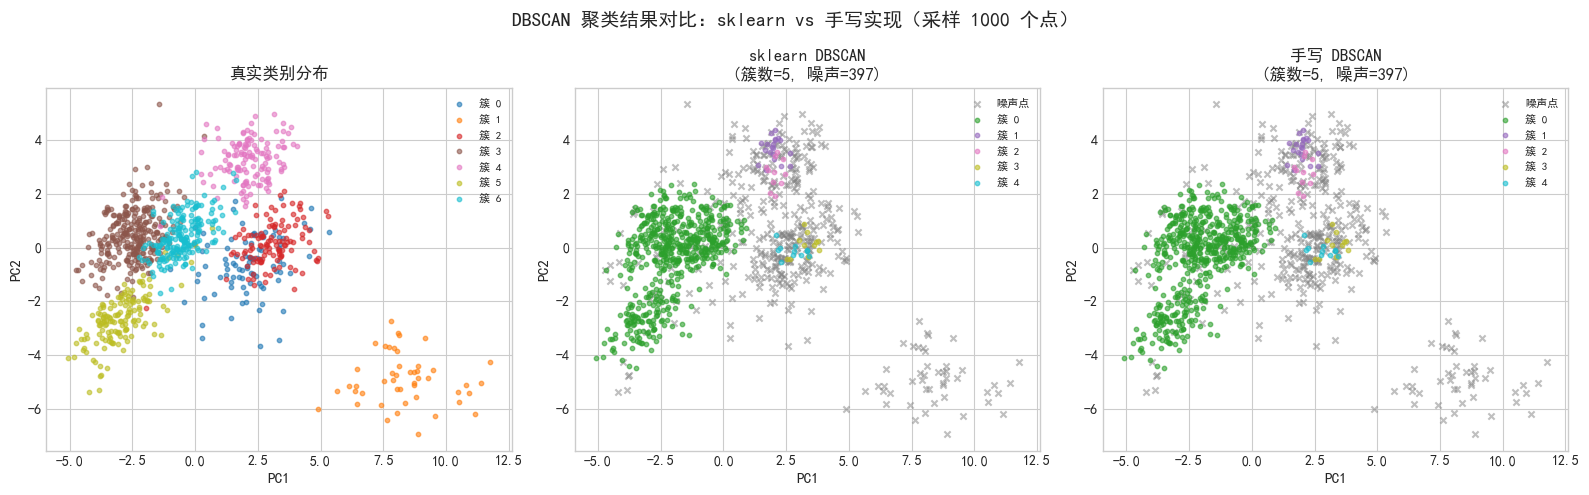


分析说明：
DBSCAN 的聚类结果依赖于 eps 和 min_samples 参数的选择。
手写实现与 sklearn 在相同参数下应产生相同或非常相近的聚类结果。
由于手写实现使用朴素的邻域搜索，时间复杂度为 O(n²)，而 sklearn 使用了 KD 树等优化。


In [41]:
# DBSCAN 结果可视化对比
# 对采样数据进行 PCA 降维
pca_dbscan = PCA(n_components=2, random_state=RANDOM_STATE)
X_dbscan_pca = pca_dbscan.fit_transform(X_dbscan_sample)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 真实标签
plot_clusters_2d(X_dbscan_pca, y_dbscan_sample, '真实类别分布', axes[0])

# sklearn DBSCAN
plot_clusters_2d(X_dbscan_pca, sklearn_dbscan_labels, f'sklearn DBSCAN\n(簇数={sklearn_n_clusters}, 噪声={sklearn_n_noise})', axes[1])

# 手写 DBSCAN
plot_clusters_2d(X_dbscan_pca, manual_dbscan_labels, f'手写 DBSCAN\n(簇数={manual_n_clusters}, 噪声={manual_n_noise})', axes[2])

plt.suptitle(f'DBSCAN 聚类结果对比：sklearn vs 手写实现（采样 {dbscan_sample_size} 个点）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n分析说明：")
print("DBSCAN 的聚类结果依赖于 eps 和 min_samples 参数的选择。")
print("手写实现与 sklearn 在相同参数下应产生相同或非常相近的聚类结果。")
print("由于手写实现使用朴素的邻域搜索，时间复杂度为 O(n²)，而 sklearn 使用了 KD 树等优化。")


### 4.1.4 手写实现与库函数对比总结

通过以上三种聚类算法的手写实现与 sklearn 库函数的对比，可以得出以下结论：

**1. K-Means 对比总结：**
- 手写实现与 sklearn 的核心算法逻辑一致
- 在相同随机种子和初始化策略下，聚类效果相近
- sklearn 版本使用了更高效的向量化计算和 k-means++ 初始化策略

**2. 层次聚类对比总结：**
- 手写实现与 sklearn 在相同 linkage 方式下产生一致的结果
- 手写实现时间复杂度为 O(n³)，sklearn 使用优化算法提升效率
- Ward linkage 在本数据集上表现最优

**3. DBSCAN 对比总结：**
- 手写实现与 sklearn 在相同参数下产生相近的聚类结果
- 手写实现使用朴素邻域搜索 O(n²)，sklearn 使用 KD 树等空间索引结构优化
- DBSCAN 对参数敏感，需根据数据分布仔细调节

**手写实现的意义：**
- 深入理解算法的核心原理和实现细节
- 认识到库函数在效率优化方面的重要作用
- 为后续算法改进和定制提供基础


### 4.1.4 算法对比汇总

将三种聚类算法在相近参数设置下的评价指标进行汇总对比。由于真实数据集有 7 个类别，我们选择 K=7（或接近 7）的参数进行对比。


In [42]:
# 汇总对比表
comparison_data = []

# K-Means (K=7)
kmeans_k7 = kmeans_df[kmeans_df['k'] == 7].iloc[0]
comparison_data.append({
    '算法': 'K-Means (K=7)',
    '簇数': 7,
    '轮廓系数': kmeans_k7['silhouette'],
    'CH 指数': kmeans_k7['calinski_harabasz'],
    'DB 指数': kmeans_k7['davies_bouldin'],
    'ARI': kmeans_k7['ari'],
    'NMI': kmeans_k7['nmi']
})

# 层次聚类 (ward, n=7)
agg_ward_7 = agg_df[(agg_df['linkage'] == 'ward') & (agg_df['n_clusters'] == 7)].iloc[0]
comparison_data.append({
    '算法': '层次聚类 (Ward, n=7)',
    '簇数': 7,
    '轮廓系数': agg_ward_7['silhouette'],
    'CH 指数': agg_ward_7['calinski_harabasz'],
    'DB 指数': agg_ward_7['davies_bouldin'],
    'ARI': agg_ward_7['ari'],
    'NMI': agg_ward_7['nmi']
})

# DBSCAN (最佳参数)
if len(valid_dbscan) > 0:
    comparison_data.append({
        '算法': f"DBSCAN (eps={best_dbscan['eps']}, min_samples={int(best_dbscan['min_samples'])})",
        '簇数': int(best_dbscan['n_clusters']),
        '轮廓系数': best_dbscan['silhouette'],
        'CH 指数': best_dbscan['calinski_harabasz'],
        'DB 指数': best_dbscan['davies_bouldin'],
        'ARI': best_dbscan['ari'],
        'NMI': best_dbscan['nmi']
    })

comparison_df = pd.DataFrame(comparison_data)
print("=" * 80)
print("聚类算法对比汇总")
print("=" * 80)
comparison_df


聚类算法对比汇总


,算法,簇数,轮廓系数,CH 指数,DB 指数,ARI,NMI
0,K-Means (K=7),7,0.308791,7787.836742,1.102132,0.666950,0.712434
1,"层次聚类 (Ward, n=7)",7,0.288623,7237.008225,1.126616,0.674928,0.730582
2,"DBSCAN (eps=0.7, min_samples=15)",7,0.314186,1408.131897,1.028905,0.263557,0.430151


---

## 4.2 Plot Result（结果可视化）

### 4.2.1 聚类结果散点图

使用 PCA 降维后的 2 维数据，对比不同聚类算法的结果和真实类别分布。


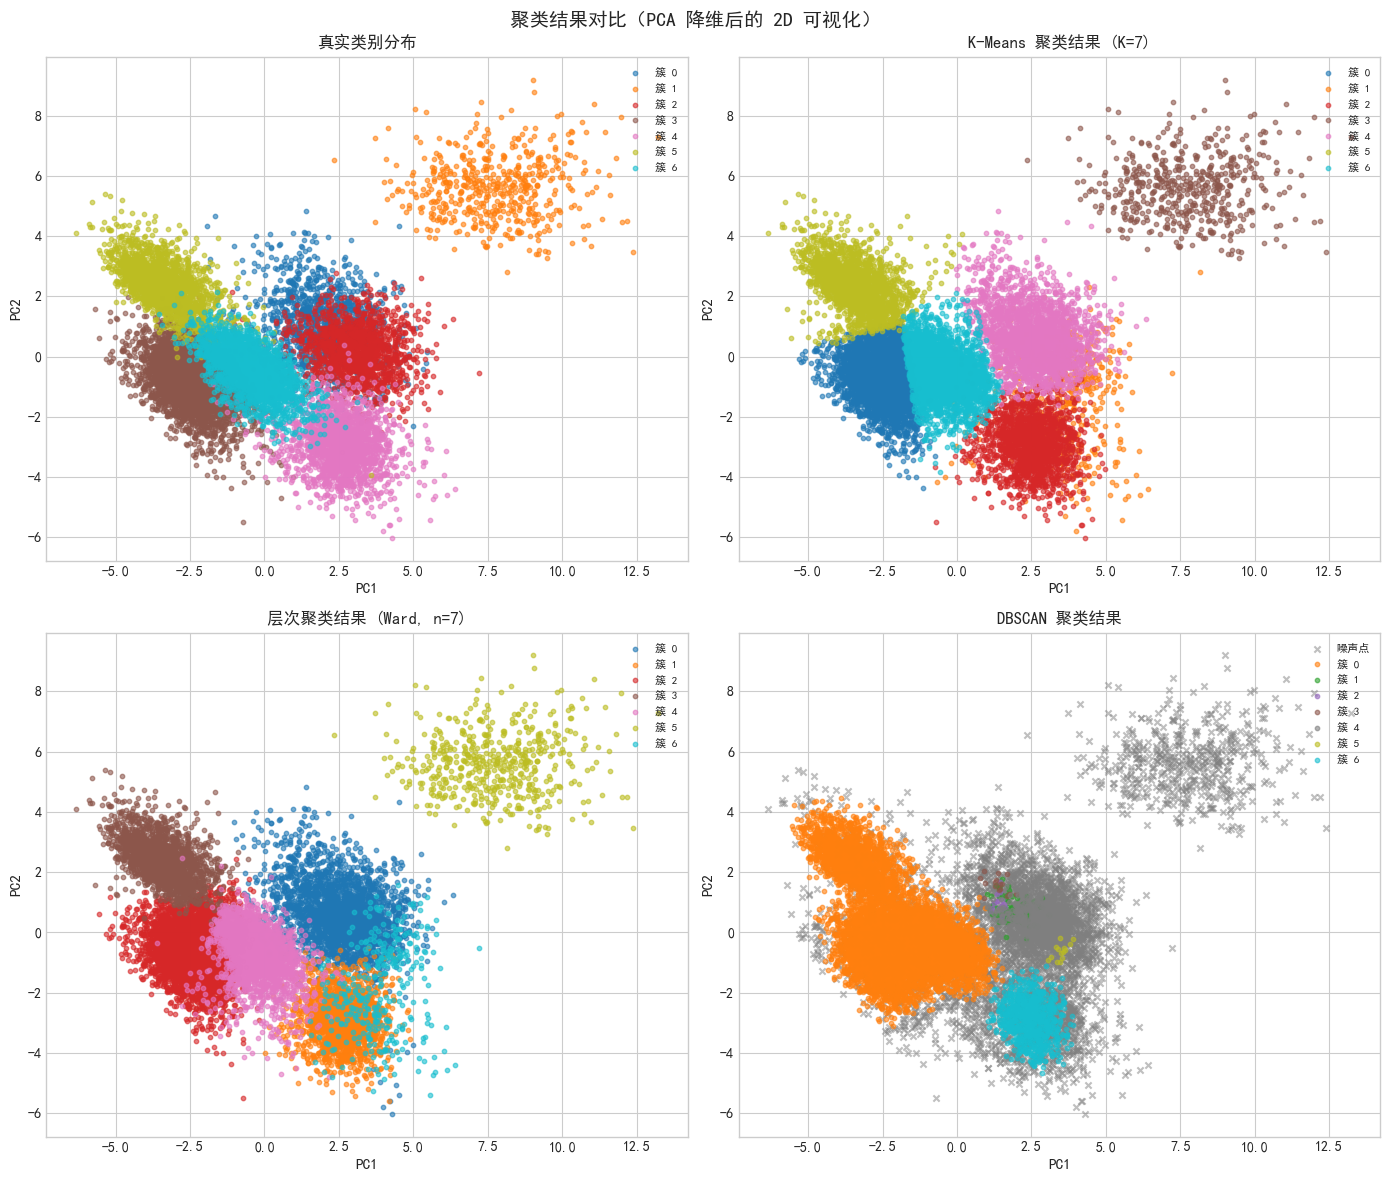

In [43]:
# 生成各算法的聚类结果（使用 K=7 或最佳参数）
kmeans_labels, _ = run_kmeans(X_scaled, 7)
agg_labels, _ = run_agglomerative(X_scaled, 7, 'ward')

# DBSCAN 使用最佳参数
if len(valid_dbscan) > 0:
    dbscan_labels, _ = run_dbscan(X_scaled, best_dbscan['eps'], int(best_dbscan['min_samples']))
else:
    # 如果没有有效结果，使用默认参数
    dbscan_labels, _ = run_dbscan(X_scaled, 1.0, 10)

# 绘制对比图
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 真实标签
plot_clusters_2d(X_pca, y, '真实类别分布', axes[0, 0])

# K-Means
plot_clusters_2d(X_pca, kmeans_labels, 'K-Means 聚类结果 (K=7)', axes[0, 1])

# 层次聚类
plot_clusters_2d(X_pca, agg_labels, '层次聚类结果 (Ward, n=7)', axes[1, 0])

# DBSCAN
plot_clusters_2d(X_pca, dbscan_labels, f'DBSCAN 聚类结果', axes[1, 1])

plt.suptitle('聚类结果对比（PCA 降维后的 2D 可视化）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.2.2 按簇分组的特征分布

通过箱线图观察不同簇在关键特征上的分布差异，帮助理解聚类的物理意义。


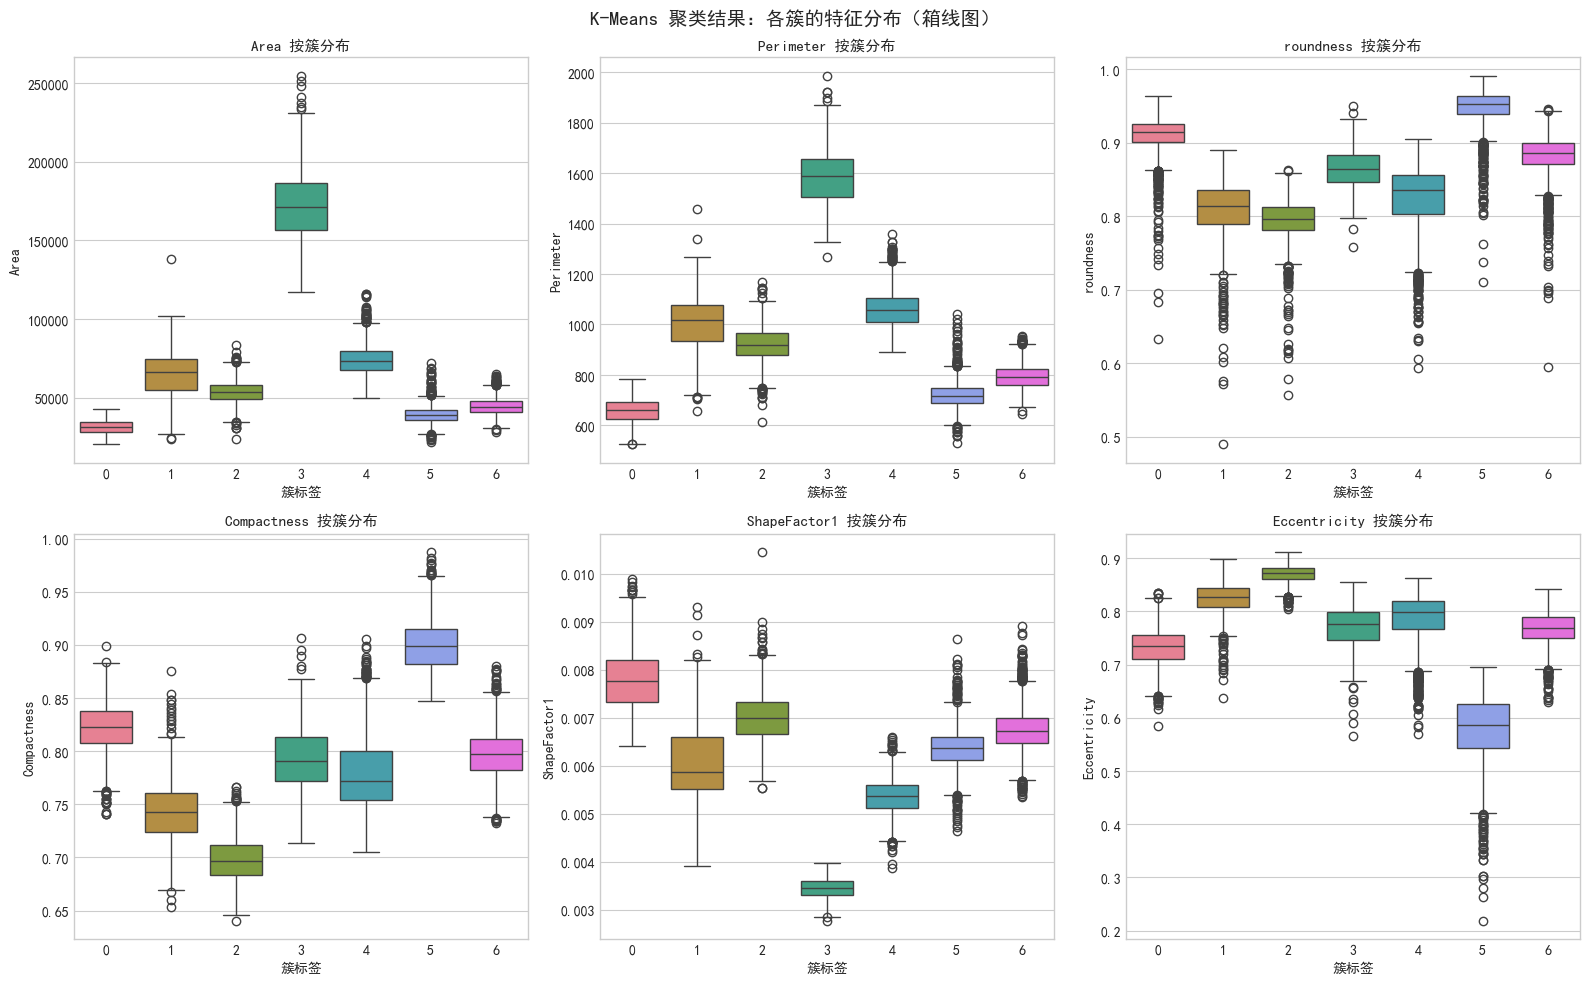

In [44]:
# 使用 K-Means 的聚类结果，绘制按簇分组的特征箱线图
df_clustered = df.copy()
df_clustered['Cluster'] = kmeans_labels

# 选择代表性特征进行可视化
features_to_plot = ['Area', 'Perimeter', 'roundness', 'Compactness', 'ShapeFactor1', 'Eccentricity']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.boxplot(data=df_clustered, x='Cluster', y=feature, ax=axes[i], palette='husl')
    axes[i].set_title(f'{feature} 按簇分布', fontsize=11)
    axes[i].set_xlabel('簇标签', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)

plt.suptitle('K-Means 聚类结果：各簇的特征分布（箱线图）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 4.3 自定义聚类视角

聚类分析并不一定要参照数据集中的原始类型标签，我们可以根据研究目的，选择特定的特征子集进行聚类分析。这里我们设计两种自定义聚类视角：

### 视角一：按"大小形态"聚类

选择与豆子大小/面积相关的特征：`Area`, `Perimeter`, `ConvexArea`, `EquivDiameter`, `MajorAxisLength`, `MinorAxisLength`

**物理意义**：按照豆子的大小和整体形态进行分组，忽略形状细节。

### 视角二：按"形状因子"聚类

选择与豆子形状特征相关的特征：`roundness`, `Compactness`, `ShapeFactor1`, `ShapeFactor2`, `ShapeFactor3`, `ShapeFactor4`, `AspectRation`, `Eccentricity`

**物理意义**：按照豆子的形状特征（圆度、紧致度等）进行分组，忽略大小差异。


In [32]:
# 定义两种特征子集
size_features = ['Area', 'Perimeter', 'ConvexArea', 'EquivDiameter', 'MajorAxisLength', 'MinorAxisLength']
shape_features = ['roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 
                  'AspectRation', 'Eccentricity']

# 提取特征子集
X_size = df[size_features].values
X_shape = df[shape_features].values

# 标准化
scaler_size = StandardScaler()
scaler_shape = StandardScaler()
X_size_scaled = scaler_size.fit_transform(X_size)
X_shape_scaled = scaler_shape.fit_transform(X_shape)

# PCA 降维用于可视化
pca_size = PCA(n_components=2, random_state=RANDOM_STATE)
pca_shape = PCA(n_components=2, random_state=RANDOM_STATE)
X_size_pca = pca_size.fit_transform(X_size_scaled)
X_shape_pca = pca_shape.fit_transform(X_shape_scaled)

print("特征子集准备完成！")
print(f"大小形态特征: {size_features}")
print(f"形状因子特征: {shape_features}")


特征子集准备完成！
大小形态特征: ['Area', 'Perimeter', 'ConvexArea', 'EquivDiameter', 'MajorAxisLength', 'MinorAxisLength']
形状因子特征: ['roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'AspectRation', 'Eccentricity']


In [33]:
# 对两个特征子集分别进行 K-Means 聚类（K=7）
labels_size, _ = run_kmeans(X_size_scaled, 7)
labels_shape, _ = run_kmeans(X_shape_scaled, 7)

# 计算评价指标
metrics_size = evaluate_clustering(X_size_scaled, labels_size, y)
metrics_shape = evaluate_clustering(X_shape_scaled, labels_shape, y)
metrics_full = evaluate_clustering(X_scaled, kmeans_labels, y)

# 汇总对比
custom_comparison = pd.DataFrame([
    {
        '聚类视角': '全特征聚类',
        '特征数': X_scaled.shape[1],
        '轮廓系数': metrics_full['silhouette'],
        'ARI': metrics_full['ari'],
        'NMI': metrics_full['nmi']
    },
    {
        '聚类视角': '大小形态聚类',
        '特征数': len(size_features),
        '轮廓系数': metrics_size['silhouette'],
        'ARI': metrics_size['ari'],
        'NMI': metrics_size['nmi']
    },
    {
        '聚类视角': '形状因子聚类',
        '特征数': len(shape_features),
        '轮廓系数': metrics_shape['silhouette'],
        'ARI': metrics_shape['ari'],
        'NMI': metrics_shape['nmi']
    }
])

print("自定义聚类视角对比（K-Means, K=7）:")
print("=" * 60)
custom_comparison


自定义聚类视角对比（K-Means, K=7）:


,聚类视角,特征数,轮廓系数,ARI,NMI
0,全特征聚类,16,0.308791,0.666950,0.712434
1,大小形态聚类,6,0.419596,0.419459,0.553844
2,形状因子聚类,8,0.337701,0.552645,0.626798


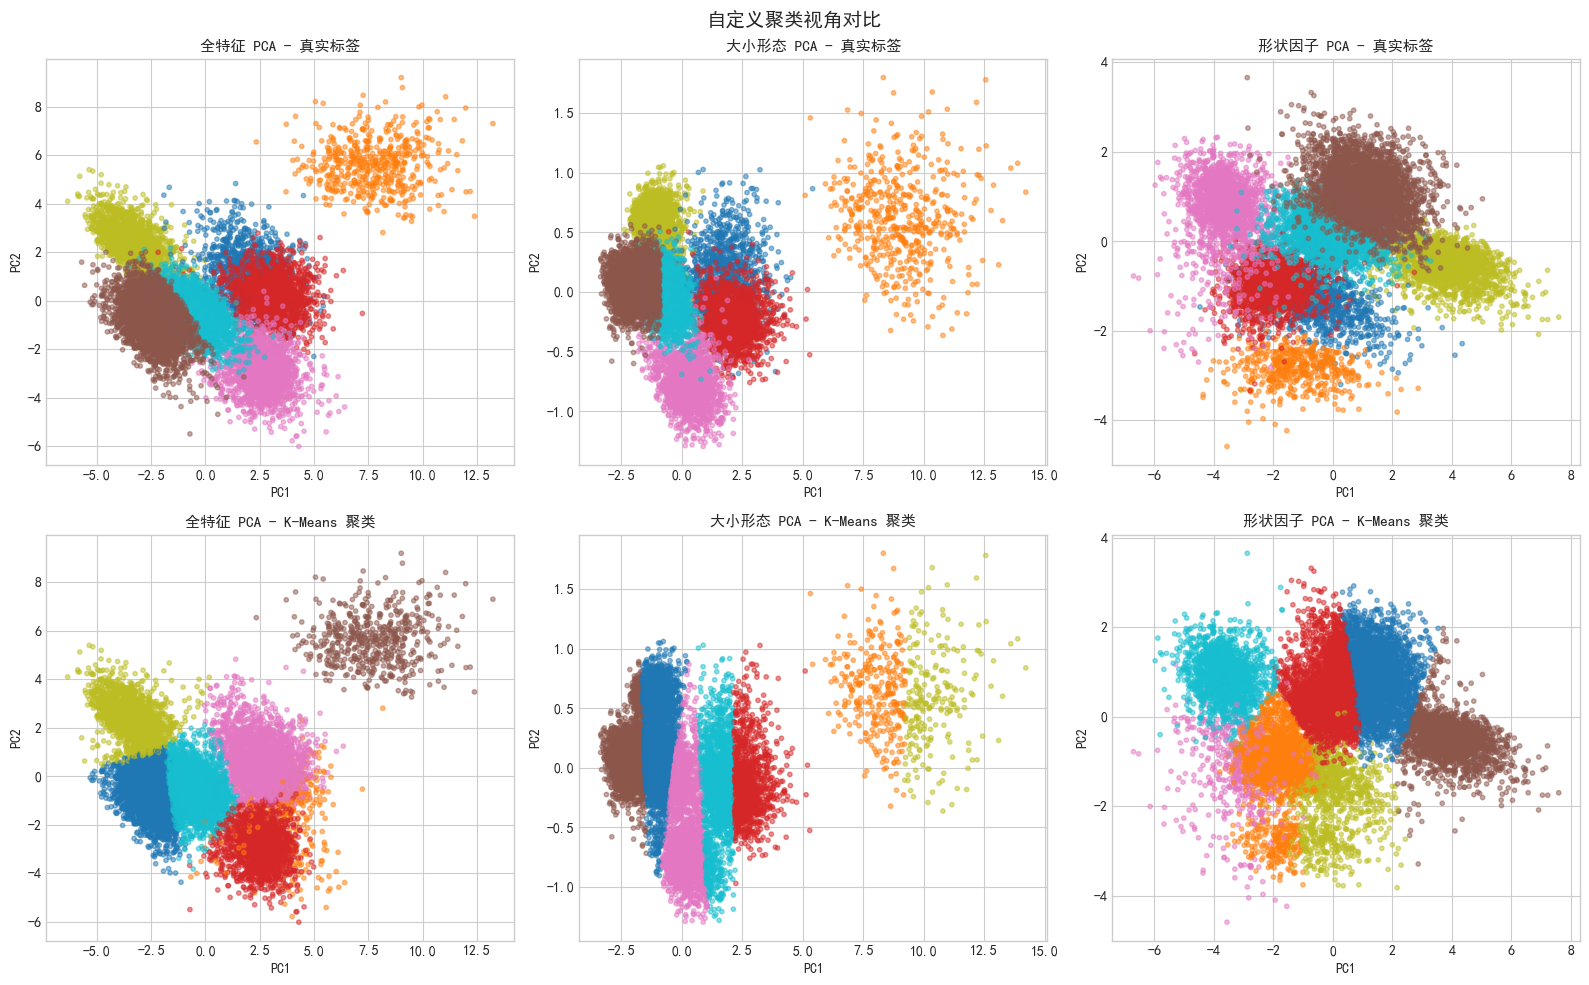

In [34]:
# 可视化自定义聚类结果
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 第一行：按真实标签着色
axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.5, s=10)
axes[0, 0].set_title('全特征 PCA - 真实标签', fontsize=11)
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')

axes[0, 1].scatter(X_size_pca[:, 0], X_size_pca[:, 1], c=y, cmap='tab10', alpha=0.5, s=10)
axes[0, 1].set_title('大小形态 PCA - 真实标签', fontsize=11)
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')

axes[0, 2].scatter(X_shape_pca[:, 0], X_shape_pca[:, 1], c=y, cmap='tab10', alpha=0.5, s=10)
axes[0, 2].set_title('形状因子 PCA - 真实标签', fontsize=11)
axes[0, 2].set_xlabel('PC1')
axes[0, 2].set_ylabel('PC2')

# 第二行：按聚类结果着色
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.5, s=10)
axes[1, 0].set_title('全特征 PCA - K-Means 聚类', fontsize=11)
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')

axes[1, 1].scatter(X_size_pca[:, 0], X_size_pca[:, 1], c=labels_size, cmap='tab10', alpha=0.5, s=10)
axes[1, 1].set_title('大小形态 PCA - K-Means 聚类', fontsize=11)
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')

axes[1, 2].scatter(X_shape_pca[:, 0], X_shape_pca[:, 1], c=labels_shape, cmap='tab10', alpha=0.5, s=10)
axes[1, 2].set_title('形状因子 PCA - K-Means 聚类', fontsize=11)
axes[1, 2].set_xlabel('PC1')
axes[1, 2].set_ylabel('PC2')

plt.suptitle('自定义聚类视角对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 自定义聚类视角分析

从上述实验结果可以观察到：

1. **大小形态聚类**：
   - 主要按豆子的尺寸大小进行分组
   - 可能会将不同品种但大小相近的豆子归为一类
   - 这种分类视角适合需要按尺寸分拣豆子的应用场景

2. **形状因子聚类**：
   - 主要按豆子的形状特征（圆度、长宽比等）进行分组
   - 忽略了大小差异，关注形状的相似性
   - 这种分类视角适合需要按形状特征区分豆子的应用场景

3. **与真实标签的对比**：
   - 通过 ARI 和 NMI 指标可以看出不同特征子集聚类与真实类别的一致程度
   - 全特征聚类通常能获得更好的效果，但特定视角的聚类可能在某些应用场景下更有意义


---

# 五、结果分析与优化

## 5.1 Optimize & Review（优化与回顾）

### 5.1.1 K-Means 参数优化

根据前面的评价指标分析，尝试不同的 K 值，比较优化效果。


In [35]:
# K-Means 参数优化对比
k_values_to_compare = [3, 5, 7, 9]
kmeans_opt_results = []

for k in k_values_to_compare:
    labels_k, _ = run_kmeans(X_scaled, k)
    metrics_k = evaluate_clustering(X_scaled, labels_k, y)
    metrics_k['K'] = k
    kmeans_opt_results.append(metrics_k)

kmeans_opt_df = pd.DataFrame(kmeans_opt_results)
print("K-Means 不同 K 值的对比:")
kmeans_opt_df[['K', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'ari', 'nmi']]


K-Means 不同 K 值的对比:


,K,silhouette,calinski_harabasz,davies_bouldin,ari,nmi
0,3,0.404448,8781.265103,0.901310,0.297649,0.485594
1,5,0.357160,8516.271732,1.025566,0.555510,0.692135
2,7,0.308791,7787.836742,1.102132,0.666950,0.712434
3,9,0.302948,7056.216420,1.164634,0.673900,0.721448


### 5.1.2 层次聚类 linkage 优化

比较不同 linkage 方式对层次聚类效果的影响。


In [36]:
# 层次聚类 linkage 优化对比（固定 n_clusters=7）
agg_opt_results = []

for linkage in ['ward', 'complete', 'average', 'single']:
    labels_agg, _ = run_agglomerative(X_scaled, 7, linkage)
    metrics_agg = evaluate_clustering(X_scaled, labels_agg, y)
    metrics_agg['linkage'] = linkage
    agg_opt_results.append(metrics_agg)

agg_opt_df = pd.DataFrame(agg_opt_results)
print("层次聚类不同 linkage 方式的对比 (n=7):")
agg_opt_df[['linkage', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'ari', 'nmi']]


层次聚类不同 linkage 方式的对比 (n=7):


,linkage,silhouette,calinski_harabasz,davies_bouldin,ari,nmi
0,ward,0.288623,7237.008225,1.126616,0.674928,0.730582
1,complete,0.160620,2446.499766,1.097044,0.157971,0.362246
2,average,0.375668,861.614304,0.839718,0.034582,0.170655
3,single,0.363406,12.712830,0.305024,0.000130,0.001198


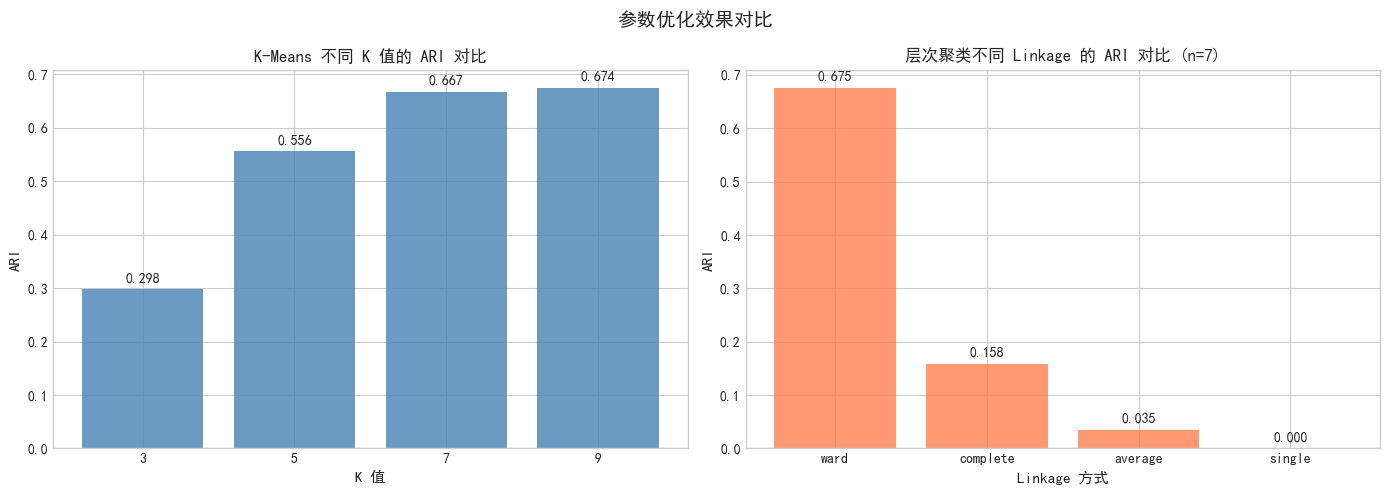

In [37]:
# 优化前后对比可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means 不同 K 值的 ARI 对比
ax1 = axes[0]
bars1 = ax1.bar(kmeans_opt_df['K'].astype(str), kmeans_opt_df['ari'], color='steelblue', alpha=0.8)
ax1.set_xlabel('K 值', fontsize=11)
ax1.set_ylabel('ARI', fontsize=11)
ax1.set_title('K-Means 不同 K 值的 ARI 对比', fontsize=12)
for bar, ari in zip(bars1, kmeans_opt_df['ari']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{ari:.3f}', ha='center', va='bottom', fontsize=10)

# 层次聚类不同 linkage 的 ARI 对比
ax2 = axes[1]
bars2 = ax2.bar(agg_opt_df['linkage'], agg_opt_df['ari'], color='coral', alpha=0.8)
ax2.set_xlabel('Linkage 方式', fontsize=11)
ax2.set_ylabel('ARI', fontsize=11)
ax2.set_title('层次聚类不同 Linkage 的 ARI 对比 (n=7)', fontsize=12)
for bar, ari in zip(bars2, agg_opt_df['ari']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{ari:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('参数优化效果对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.1.3 综合分析

**算法效果对比分析：**

1. **K-Means 聚类**
   - 优点：计算速度快，易于理解和实现
   - 缺点：需要预先指定簇数 K，对初始中心点敏感
   - 在本数据集上：当 K=7（与真实类别数相同）时，能获得较好的聚类效果

2. **层次聚类（Agglomerative）**
   - 优点：不需要预先指定簇数，可以生成层次结构
   - 缺点：计算复杂度较高，对大数据集不太适用
   - 在本数据集上：Ward 连接方式表现最好，与 K-Means 效果相当

3. **DBSCAN**
   - 优点：能发现任意形状的簇，能自动识别噪声点，不需要指定簇数
   - 缺点：对参数（eps、min_samples）敏感，在高维数据上效果可能不佳
   - 在本数据集上：由于数据在高维空间中分布较为分散，DBSCAN 可能产生较多噪声点

**参数选择的影响：**
- K-Means 的簇数 K 直接影响聚类粒度，K 值过大或过小都会降低聚类质量
- 层次聚类的 linkage 方式影响簇的形状和合并策略，Ward 方法在本数据集上表现最优
- DBSCAN 的 eps 和 min_samples 需要根据数据密度分布仔细调节

**局限性分析：**
- 数据集中某些类别可能存在重叠，导致聚类边界模糊
- 高维特征空间中的距离度量可能不够有效
- 真实类别的定义可能与几何特征的自然聚类结构不完全一致


---

# 六、实验总结

## 6.1 主要发现

通过本次实验，我获得了以下主要发现：

1. **聚类算法的选择**：不同聚类算法有各自的优缺点，应根据数据特点和应用场景选择合适的算法。K-Means 适合球形簇，计算效率高；层次聚类适合需要层次结构的场景；DBSCAN 适合发现任意形状的簇和处理噪声。

2. **参数调优的重要性**：聚类算法的效果对参数设置非常敏感。通过系统地尝试不同参数并使用评价指标进行比较，可以找到相对最优的参数组合。

3. **评价指标的选择**：内部评价指标（轮廓系数、CH 指数、DB 指数）适合在没有真实标签时评估聚类质量；外部评价指标（ARI、NMI）需要真实标签，但能更直观地反映聚类与真实分类的一致性。

4. **特征选择的影响**：不同的特征子集会产生不同的聚类结果。根据具体应用场景选择合适的特征子集，可以得到更有意义的聚类结果。

5. **数据预处理的必要性**：特征标准化对于基于距离的聚类算法至关重要，可以避免某些特征主导距离计算。

## 6.2 收获与体会

1. 深入理解了无监督学习中聚类分析的基本概念和常用算法
2. 掌握了使用 scikit-learn 库实现聚类分析的方法
3. 学会了使用多种评价指标评估聚类效果
4. 理解了特征工程和参数调优对聚类结果的重要影响
5. 提高了数据可视化和结果分析的能力


---

# 七、参考文献

1. **数据集来源**：
   - Dry Bean Dataset - UCI Machine Learning Repository / Kaggle
   - Koklu, M. and Ozkan, I.A., (2020). Multiclass Classification of Dry Beans Using Computer Vision and Machine Learning Techniques. Computers and Electronics in Agriculture, 174, 105507.

2. **使用的主要算法和库**：
   - scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011
   - K-Means 聚类算法: MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations.
   - 层次聚类: Rokach, L., & Maimon, O. (2005). Clustering methods. Data mining and knowledge discovery handbook.
   - DBSCAN: Ester, M., et al. (1996). A density-based algorithm for discovering clusters in large spatial databases with noise.

3. **评价指标参考**：
   - Rousseeuw, P.J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis.
   - Hubert, L., & Arabie, P. (1985). Comparing partitions. Journal of classification.

---

**实验完成！**
